# 极大似然估计 (Maximum Likelihood Estimation)

> 一份面向初学者的中文互动教学 notebook。从"概率 vs 似然"讲到"为什么交叉熵 / MSE 都是 MLE"，让你能自己动手推导、手算、可视化。

**为什么值得反复学 MLE？**

- 逻辑回归、softmax 分类、语言模型和 Normalizing Flow 可以直接写成最大似然训练；VAE、扩散模型等则常通过 ELBO、去噪或 score matching 等可计算的代理目标，间接连接到似然建模。
- PyTorch / TensorFlow 里最常用的 `BCELoss`、`MSELoss`、`CrossEntropyLoss` 都是 MLE 在特定概率模型下的实现。
- 理解 MLE 后，你会看清"损失函数不是拍脑袋定的，而是从概率假设推出来的"。

**教程约定**

每一章都围绕 7 个问题展开：

1. 这一节到底想解决什么问题？
2. 前面知识不足在哪里？
3. 核心思想是什么？
4. 数学怎么写？
5. 拿一组具体数字怎么手算？
6. 用代码画出来是什么样？
7. 什么时候会踩坑？

从上往下依次运行代码单元。所有例子都用小规模玩具数据，不需要下载任何外部数据集。

## 0 · 环境准备与绘图约定

这一节只做三件事：

1. 导入后续要用的库。
2. 设定统一的绘图风格（含中文字体回退）。
3. 固定随机种子，让你复现同样的数字。

如果 import 失败，回到 README 的"快速开始"重新执行 `uv sync`。

In [1]:
import math
import sys
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import optimize, stats

try:
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

SEED = 42
rng = np.random.default_rng(SEED)

# 中文字体回退：如果系统里有中文字体，让图表标题/标签显示中文。
_cjk_candidates = ["PingFang SC", "Arial Unicode MS", "Heiti TC", "Songti SC",
                   "STHeiti", "Microsoft YaHei", "SimHei"]
_installed = {f.name for f in fm.fontManager.ttflist}
_cjk = [f for f in _cjk_candidates if f in _installed]
if _cjk:
    plt.rcParams["font.sans-serif"] = _cjk + plt.rcParams.get("font.sans-serif", [])

plt.rcParams.update({
    "figure.figsize": (8.5, 4.6),
    "figure.dpi": 115,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#ffffff",
    "axes.unicode_minus": False,
})

COLORS = {
    "blue":   "#2563eb",
    "green":  "#059669",
    "red":    "#dc2626",
    "amber":  "#d97706",
    "purple": "#7c3aed",
    "gray":   "#6b7280",
    "pink":   "#db2777",
    "teal":   "#0d9488",
}

print("Python:", sys.version.split()[0])
print("numpy :", np.__version__)
print("scipy :", __import__("scipy").__version__)
print("widgets available:", HAS_WIDGETS)
print("CJK fonts detected:", _cjk if _cjk else "(none, 图表中文可能显示为方块)")

Python: 3.12.9
numpy : 2.5.1
scipy : 1.18.0
widgets available: True
CJK fonts detected: ['PingFang SC', 'Arial Unicode MS', 'Heiti TC', 'Songti SC', 'STHeiti']


## 1 · 概率 vs 似然：看似同一个式子，视角完全不同

MLE 的所有直觉都来自一件事：**"概率"和"似然"其实是同一个数学表达式，只是自变量不同**。

用一枚硬币来演示。设正面朝上的真实概率是 $\theta$。抛 $n$ 次，观察到 $k$ 次正面的概率是：

$$
P(k \mid \theta) = \binom{n}{k}\, \theta^{k}(1-\theta)^{n-k}
$$

- **概率视角**：**把 $\theta$ 固定**（比如 $\theta = 0.6$），把 $k$ 看作变量，问"我下次实验最可能看到哪个 $k$？"—— 得到一张关于 $k$ 的柱状图。
- **似然视角**：**把观测 $k$ 固定**（比如你实际抛了 10 次，看到 7 次正面），把 $\theta$ 看作变量，问"哪个 $\theta$ 让这次观测最可能发生？"—— 得到一条关于 $\theta$ 的曲线。

后者，就是**似然函数 $L(\theta)$**。它长得和上面公式一模一样，但**自变量不再是数据而是参数**。这一步视角切换，就是 Fisher (1922) 提出的 MLE 的全部起点。

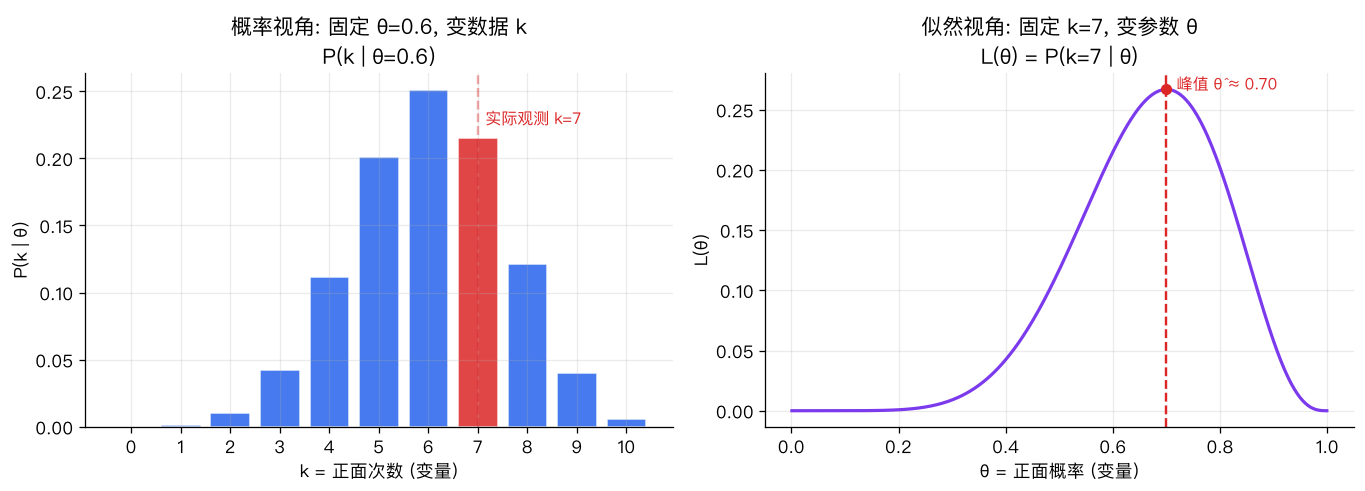

视角 A: 概率, 曲线积分 = 1 (对 k 求和)。 求和 = 1.0
视角 B: 似然, 曲线积分 ≠ 1 (对 θ 积分)。 积分 ≈ 0.090909


In [2]:
from math import comb

n = 10
theta_true = 0.6
k_obs = 7  # 假设我们观测到 7 正 3 反

# --- 视角 A: 固定 θ = 0.6, 变 k -----------------------------------------
ks = np.arange(0, n + 1)
probs_given_theta = np.array([comb(n, k) * theta_true**k * (1 - theta_true)**(n - k)
                              for k in ks])

# --- 视角 B: 固定 k = 7, 变 θ -------------------------------------------
thetas = np.linspace(0.001, 0.999, 400)
likelihood_given_k = comb(n, k_obs) * thetas**k_obs * (1 - thetas)**(n - k_obs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

ax = axes[0]
bar_colors = [COLORS["blue"] if k != k_obs else COLORS["red"] for k in ks]
ax.bar(ks, probs_given_theta, color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_title(f"概率视角: 固定 θ={theta_true}, 变数据 k\nP(k | θ=0.6)")
ax.set_xlabel("k = 正面次数 (变量)")
ax.set_ylabel("P(k | θ)")
ax.set_xticks(ks)
ax.axvline(k_obs, color=COLORS["red"], linestyle="--", alpha=0.4)
ax.text(k_obs + 0.15, max(probs_given_theta) * 0.9,
        f"实际观测 k={k_obs}", color=COLORS["red"], fontsize=10)

ax = axes[1]
ax.plot(thetas, likelihood_given_k, color=COLORS["purple"], lw=2)
mle_idx = np.argmax(likelihood_given_k)
ax.axvline(thetas[mle_idx], color=COLORS["red"], linestyle="--")
ax.scatter([thetas[mle_idx]], [likelihood_given_k[mle_idx]],
           color=COLORS["red"], zorder=5)
ax.text(thetas[mle_idx] + 0.02, likelihood_given_k[mle_idx],
        f"峰值 θ̂ ≈ {thetas[mle_idx]:.2f}", color=COLORS["red"], fontsize=10)
ax.set_title(f"似然视角: 固定 k={k_obs}, 变参数 θ\nL(θ) = P(k=7 | θ)")
ax.set_xlabel("θ = 正面概率 (变量)")
ax.set_ylabel("L(θ)")

plt.tight_layout()
plt.show()

print("视角 A: 概率, 曲线积分 = 1 (对 k 求和)。 求和 =", probs_given_theta.sum().round(6))
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
print("视角 B: 似然, 曲线积分 ≠ 1 (对 θ 积分)。 积分 ≈",
      _trapz(likelihood_given_k, thetas).round(6))

### 关键区别一句话

- $P(k \mid \theta)$：对 $k$ 求和 = 1，是**概率分布**。
- $L(\theta) = P(k_{\text{obs}} \mid \theta)$：对 $\theta$ 积分不一定等于 1，**不是** $\theta$ 的概率分布，而是一条"看数据后关于参数的评分曲线"。

MLE 的核心命题是：**在这条评分曲线的最高点，选一个 $\theta$ 作为参数估计**。也就是
$$
\hat\theta_{\text{MLE}} = \arg\max_{\theta}\, L(\theta).
$$

上图中，红色虚线正好落在 $\hat\theta = 0.7$：因为我们观测到了 7/10 正面，让这个观测最"合理"的 $\theta$ 就是 0.7。注意这个值**并不等于真值 0.6**——观测数据有限，MLE 也只是一个估计。

## 2 · 似然函数与对数似然：为什么优化的是 $\log L$

假设我们独立地观测到 $n$ 个样本 $x_1, x_2, \dots, x_n$（i.i.d. 假设：independent and identically distributed）。整个数据集的联合概率就是各样本概率的乘积：

$$
L(\theta) = \prod_{i=1}^{n} p(x_i \mid \theta)
$$

这条式子非常有用，但**在数值上很难直接优化**：

- 每个 $p(x_i \mid \theta) \le 1$，$n$ 上百上千个数相乘，结果小到浮点数下溢为 0。
- 求导时乘积规则展开非常繁琐。

**技巧**：取自然对数（严格单调递增，不改变 argmax），把乘积变成求和：

$$
\ell(\theta) = \log L(\theta) = \sum_{i=1}^{n} \log p(x_i \mid \theta)
$$

- 加法比乘法在浮点数下稳定得多。
- 求导时链式法则简单：$\frac{\partial \ell}{\partial \theta} = \sum_i \frac{\partial \log p(x_i \mid \theta)}{\partial \theta}$。
- 深度学习里我们直接反过来定义损失：**负对数似然 (NLL)** = $-\ell(\theta)$，把"最大化 $\ell$"变成"最小化 NLL"，正好对齐梯度下降的最小化框架。

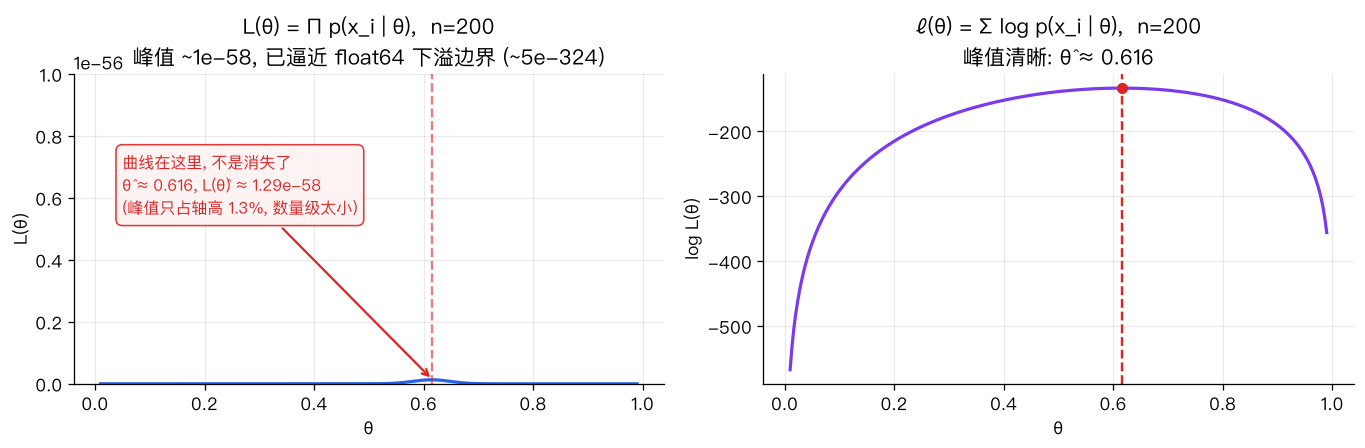

直接 likelihood 峰值 L(θ̂):         1.294e-58   (~1e-58, 极小)
直接 likelihood 在 θ=0.6 时:      1.178e-58
log-likelihood 在 θ=0.6 时:        -133.3859
两条曲线 argmax 都落在 θ=0.616, 但在 [0,1] 尺度上 L 完全看不出峰值。


In [3]:
# 演示: n=200 个 Bernoulli 样本, 直接乘 vs 取 log
n_demo = 200
theta_star = 0.6
samples = rng.binomial(1, theta_star, size=n_demo)

def likelihood_scalar(theta, x):
    # 直接乘, 结果小到接近 0
    p = np.where(x == 1, theta, 1 - theta)
    return float(np.prod(p))

def log_likelihood_scalar(theta, x):
    p = np.where(x == 1, theta, 1 - theta)
    return float(np.sum(np.log(p)))

thetas = np.linspace(0.01, 0.99, 300)
L_direct = np.array([likelihood_scalar(t, samples) for t in thetas])
loglik   = np.array([log_likelihood_scalar(t, samples) for t in thetas])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# 关键: 用一个"略大于峰值"的固定上限, 让峰值只占轴高的一小段,
# 曲线看起来接近平坦, 才能对应"数值上就是 0, 峰值信息几乎丢失"的教学结论。
# 峰值 ~1.3e-58, 这里取 1e-56 (约 77×峰值), 峰只占轴高 ~1.3%。
Y_TOP = 1e-56
axes[0].plot(thetas, L_direct, color=COLORS["blue"], lw=2)
axes[0].set_title(f"L(θ) = ∏ p(x_i | θ),  n={n_demo}\n峰值 ~1e-58, 已逼近 float64 下溢边界 (~5e-324)")
axes[0].set_xlabel("θ"); axes[0].set_ylabel("L(θ)")
axes[0].set_ylim(0, Y_TOP)
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
peak_L_idx = int(np.argmax(L_direct))
axes[0].axvline(thetas[peak_L_idx], color=COLORS["red"], linestyle="--", alpha=0.6)
axes[0].annotate(f"曲线在这里, 不是消失了\nθ̂ ≈ {thetas[peak_L_idx]:.3f}, L(θ̂) ≈ {L_direct.max():.2e}\n(峰值只占轴高 {L_direct.max()/Y_TOP*100:.1f}%, 数量级太小)",
                 xy=(thetas[peak_L_idx], L_direct.max()),
                 xytext=(0.05, Y_TOP * 0.55),
                 color=COLORS["red"], fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.4", fc="#fef2f2",
                           ec=COLORS["red"], alpha=0.9),
                 arrowprops=dict(arrowstyle="->", color=COLORS["red"], lw=1.4))

axes[1].plot(thetas, loglik, color=COLORS["purple"], lw=2)
peak_theta = thetas[np.argmax(loglik)]
axes[1].axvline(peak_theta, color=COLORS["red"], linestyle="--")
axes[1].scatter([peak_theta], [loglik.max()], color=COLORS["red"], zorder=5)
axes[1].set_title(f"ℓ(θ) = Σ log p(x_i | θ),  n={n_demo}\n峰值清晰: θ̂ ≈ {peak_theta:.3f}")
axes[1].set_xlabel("θ"); axes[1].set_ylabel("log L(θ)")

plt.tight_layout(); plt.show()

print(f"直接 likelihood 峰值 L(θ̂):         {L_direct.max():.3e}   (~1e-58, 极小)")
print(f"直接 likelihood 在 θ=0.6 时:      {likelihood_scalar(0.6, samples):.3e}")
print(f"log-likelihood 在 θ=0.6 时:        {log_likelihood_scalar(0.6, samples):.4f}")
print(f"两条曲线 argmax 都落在 θ={peak_theta:.3f}, 但在 [0,1] 尺度上 L 完全看不出峰值。")

### 小结：三种等价写法

在文献和代码里，你会看到 MLE 有很多等价说法，它们指的是**同一个优化问题**：

| 表达 | 目标 | 说明 |
|------|------|------|
| $\max_\theta \prod_i p(x_i \mid \theta)$ | 最大化似然 | 教科书最原始形式 |
| $\max_\theta \sum_i \log p(x_i \mid \theta)$ | 最大化对数似然 | 数值稳定, 便于求导 |
| $\min_\theta -\sum_i \log p(x_i \mid \theta)$ | 最小化负对数似然 (NLL) | 深度学习里最常见 |
| $\min_\theta \tfrac{1}{n}\sum_i \big[-\log p(x_i \mid \theta)\big]$ | 最小化平均 NLL | 与 batch size 解耦 |

**记住**：优化 $L$、$\log L$、$-\log L$、平均 $-\log L$，**argmax / argmin 完全一样**。区别只是数值和习惯。

## 3 · 手算：Bernoulli 分布的 MLE

场景：一枚硬币抛 $n$ 次，其中 $k$ 次正面。设正面概率为 $\theta \in (0, 1)$。

**第 1 步：写出似然**
$$
L(\theta) = \theta^k (1-\theta)^{n-k}
$$
（这里省略了组合数 $\binom{n}{k}$，因为它不依赖 $\theta$，对 argmax 无影响。）

**第 2 步：取对数**
$$
\ell(\theta) = k\log\theta + (n-k)\log(1-\theta)
$$

**第 3 步：对 $\theta$ 求导并令其为 0**
$$
\frac{d\ell}{d\theta} = \frac{k}{\theta} - \frac{n-k}{1-\theta} = 0
$$

**第 4 步：解方程**
$$
k(1-\theta) = (n-k)\theta
\;\Longrightarrow\;
k - k\theta = n\theta - k\theta
\;\Longrightarrow\;
\boxed{\; \hat\theta_{\text{MLE}} = \frac{k}{n} \;}
$$

**结论**：Bernoulli MLE 就是**样本平均**。这也是"频率派最直白的估计"—— 观测中正面出现的比例就是你对 $\theta$ 的最好猜测。

In [4]:
# --- 手算演示: n=10, k=7 ------------------------------------------------
n, k = 10, 7
theta_hat = k / n
print(f"手算: k/n = {k}/{n} = {theta_hat}")

# 用几个不同 θ 手动列表, 感受"最优点"
thetas_probe = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]
print(f"\n{'θ':>6} | {'L(θ)':>12} | {'log L(θ)':>12}")
print("-" * 40)
for t in thetas_probe:
    L = t**k * (1 - t)**(n - k)
    logL = k * math.log(t) + (n - k) * math.log(1 - t)
    marker = "  <-- MLE" if t == theta_hat else ""
    print(f"{t:>6.2f} | {L:>12.6f} | {logL:>12.4f}{marker}")

print(f"\n手算 L(0.7) = 0.7^7 * 0.3^3")
print(f"            = {0.7**7:.6f} * {0.3**3:.6f}")
print(f"            = {0.7**7 * 0.3**3:.6f}")

手算: k/n = 7/10 = 0.7

     θ |         L(θ) |     log L(θ)
----------------------------------------
  0.30 |     0.000075 |      -9.4978
  0.50 |     0.000977 |      -6.9315
  0.60 |     0.001792 |      -6.3247
  0.70 |     0.002224 |      -6.1086  <-- MLE
  0.80 |     0.001678 |      -6.3903
  0.90 |     0.000478 |      -7.6453

手算 L(0.7) = 0.7^7 * 0.3^3
            = 0.082354 * 0.027000
            = 0.002224


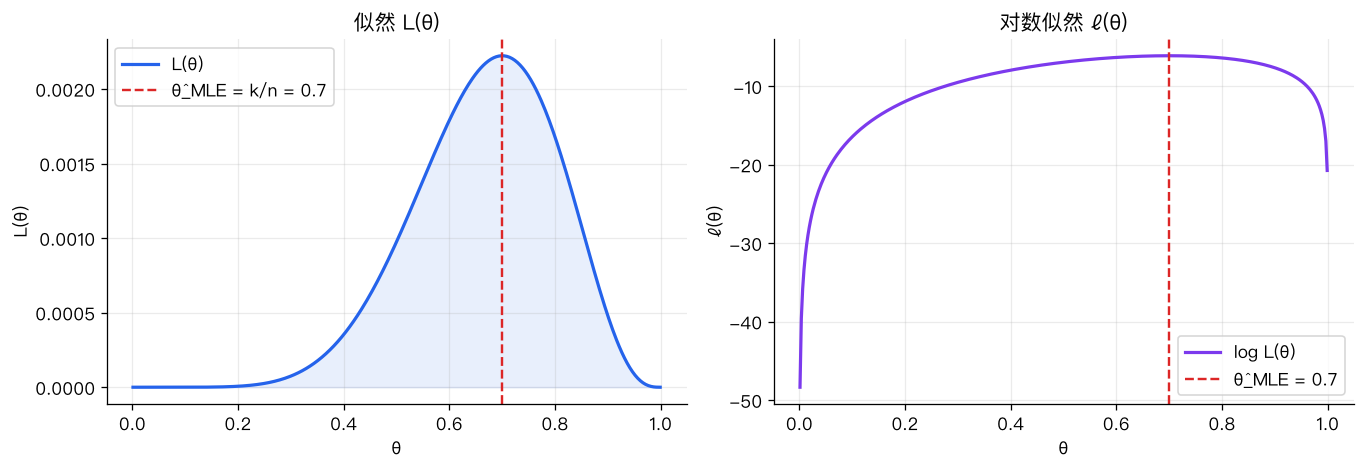

In [5]:
# --- 可视化: L(θ) 与 ℓ(θ), 标出 MLE 与真值 ------------------------------
n, k = 10, 7
thetas = np.linspace(0.001, 0.999, 400)
L      = thetas**k * (1 - thetas)**(n - k)
logL   = k * np.log(thetas) + (n - k) * np.log(1 - thetas)
theta_hat = k / n

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(thetas, L, color=COLORS["blue"], lw=2, label="L(θ)")
axes[0].axvline(theta_hat, color=COLORS["red"], linestyle="--",
                label=f"θ̂_MLE = k/n = {theta_hat}")
axes[0].fill_between(thetas, 0, L, alpha=0.10, color=COLORS["blue"])
axes[0].set_title("似然 L(θ)")
axes[0].set_xlabel("θ"); axes[0].set_ylabel("L(θ)")
axes[0].legend()

axes[1].plot(thetas, logL, color=COLORS["purple"], lw=2, label="log L(θ)")
axes[1].axvline(theta_hat, color=COLORS["red"], linestyle="--",
                label=f"θ̂_MLE = {theta_hat}")
axes[1].set_title("对数似然 ℓ(θ)")
axes[1].set_xlabel("θ"); axes[1].set_ylabel("ℓ(θ)")
axes[1].legend()

plt.tight_layout(); plt.show()

### 交互实验：拖动滑动条

如果本地环境支持 `ipywidgets`，运行下面的 cell，可以自由改变正面次数 $k$ 和总次数 $n$，实时看到似然峰值的移动。观察三件事：

1. 当 $n$ 变大而正面比例保持 0.7 时，曲线变**尖**（数据越多参数越确定）。
2. 当 $k=0$ 或 $k=n$ 时，MLE 会落在边界 $\theta=0$ 或 $\theta=1$，这是 MLE 的一个著名"边界解"陷阱。
3. 曲线始终以 $\theta = k/n$ 为峰。

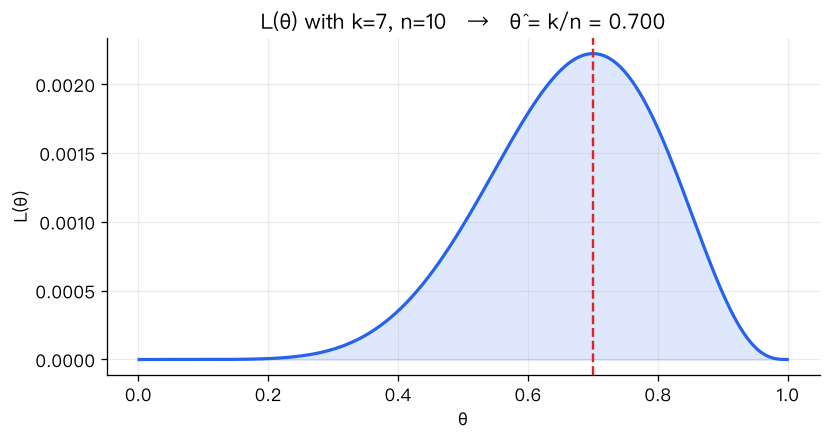

interactive(children=(IntSlider(value=7, description='k (正面次数)', max=10), IntSlider(value=10, description='n (…

In [6]:
def plot_bernoulli_likelihood(k=7, n=10):
    if n < 1:
        print("n 必须至少为 1"); return
    if not 0 <= k <= n:
        print(f"参数无效: 必须满足 0 ≤ k ≤ n，当前 k={k}, n={n}"); return
    thetas = np.linspace(0.001, 0.999, 400)
    L = thetas**k * (1 - thetas)**(n - k)
    theta_hat = k / n if 0 < k < n else (0.0 if k == 0 else 1.0)

    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(thetas, L, color=COLORS["blue"], lw=2)
    ax.fill_between(thetas, 0, L, alpha=0.15, color=COLORS["blue"])
    ax.axvline(theta_hat, color=COLORS["red"], linestyle="--")
    ax.set_title(f"L(θ) with k={k}, n={n}   →   θ̂ = k/n = {theta_hat:.3f}")
    ax.set_xlabel("θ"); ax.set_ylabel("L(θ)")
    plt.show()

# 静态默认演示 (无 widgets 也能看)
plot_bernoulli_likelihood(k=7, n=10)

if HAS_WIDGETS:
    bernoulli_k_slider = IntSlider(value=7, min=0, max=10, step=1, description="k (正面次数)")
    bernoulli_n_slider = IntSlider(value=10, min=1, max=50, step=1, description="n (总次数)")

    def sync_bernoulli_k_range(change):
        bernoulli_k_slider.max = change["new"]
        if bernoulli_k_slider.value > change["new"]:
            bernoulli_k_slider.value = change["new"]

    bernoulli_n_slider.observe(sync_bernoulli_k_range, names="value")
    interact(plot_bernoulli_likelihood,
             k=bernoulli_k_slider,
             n=bernoulli_n_slider);

## 4 · 手算：高斯分布 (Gaussian) 的 MLE

场景：观测到 $n$ 个实数样本 $x_1, \dots, x_n$，假设它们独立同分布服从 $\mathcal{N}(\mu, \sigma^2)$。参数 $\theta = (\mu, \sigma^2)$。

**Step 1. 写出单点似然**
$$
p(x_i \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp\!\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)
$$

**Step 2. 联合似然 (n 个 i.i.d. 样本的乘积)**
$$
L(\mu, \sigma^2)
= \prod_{i=1}^{n} p(x_i \mid \mu, \sigma^2)
= \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi \sigma^2}} \exp\!\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)
$$

**Step 3. 逐项化简对数似然**

先把乘积拆成两个部分：常系数和指数。

$$
L(\mu, \sigma^2)
= \underbrace{\left(\frac{1}{\sqrt{2\pi \sigma^2}}\right)^{n}}_{\text{n 个常系数相乘}}
\cdot
\underbrace{\exp\!\left(-\sum_{i=1}^{n}\frac{(x_i - \mu)^2}{2\sigma^2}\right)}_{\text{n 个 exp 相乘, 指数相加}}
$$

对两边取自然对数，`log(ab) = log a + log b`, `log(exp(y)) = y`：

$$
\ell(\mu, \sigma^2) = \log L
= n \log\!\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)
\;+\;
\left(-\sum_{i=1}^{n}\frac{(x_i - \mu)^2}{2\sigma^2}\right)
$$

**Step 4. 展开常数项** `log(1/√(2πσ²)) = -½ log(2πσ²) = -½ log(2π) - ½ log(σ²)`：

$$
n \log\!\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)
= -\frac{n}{2}\log(2\pi\sigma^2)
= -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log \sigma^2
$$

**Step 5. 提取指数项里的公共因子** `1/(2σ²)` 不随 `i` 变化：

$$
-\sum_{i=1}^{n}\frac{(x_i - \mu)^2}{2\sigma^2}
= -\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2
$$

**Step 6. 合并三项**

$$
\boxed{\;
\ell(\mu, \sigma^2)
= \underbrace{-\frac{n}{2}\log(2\pi)}_{\text{常数, 与参数无关}}
\;-\; \underbrace{\frac{n}{2}\log \sigma^2}_{\text{惩罚方差过大}}
\;-\; \underbrace{\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2}_{\text{惩罚残差平方 (与 MSE 同形)}}
\;}
$$

三项的物理意义：

| 项 | 依赖 | 直觉 |
|----|------|------|
| $-\tfrac{n}{2}\log(2\pi)$ | 都不依赖 | 归一化常数, 求 argmax 时直接扔掉 |
| $-\tfrac{n}{2}\log \sigma^2$ | 仅依赖 $\sigma^2$ | 方差越大越"松弛", 但每个样本的概率密度也会被拉低 → 惩罚项 |
| $-\tfrac{1}{2\sigma^2}\sum(x_i-\mu)^2$ | 依赖 $\mu, \sigma^2$ | 残差平方和 (SSE)。**如果 $\sigma$ 已知**, 这一项就是 $-\tfrac{1}{2\sigma^2}\cdot \text{MSE} \cdot n$, 最大化它 = 最小化 MSE。这里就是"MSE 从哪来"的答案。|

**Step 7 (可选). 常用简化**

- `argmax` 与常数无关, 所以做优化时可以直接扔掉 $-\tfrac{n}{2}\log(2\pi)$。
- 有时把方差写成 $\tau = \sigma^2$ 让求导更清爽 (下面就是这样做的)。

下面我们对 $\mu$ 和 $\sigma^2$ 分别求偏导。

**Step 8. 对 $\mu$ 求偏导 (把 $\sigma^2$ 当作常数)**

只有第三项含 $\mu$。用链式法则 $\frac{d}{d\mu}(x_i-\mu)^2 = -2(x_i - \mu)$：

$$
\frac{\partial \ell}{\partial \mu}
= -\frac{1}{2\sigma^2}\sum_{i} \cdot (-2)(x_i - \mu)
= \frac{1}{\sigma^2}\sum_{i}(x_i - \mu)
$$

令其为 0：$\sum_i (x_i - \mu) = 0 \Rightarrow \sum_i x_i = n\mu$，得

$$
\boxed{\; \hat\mu = \frac{1}{n}\sum_{i=1}^{n} x_i \;}
$$

样本均值。**注意**：这个解和 $\sigma^2$ 完全无关——把 $\sigma^2$ 当参数还是当已知值，$\hat\mu$ 都是均值。

**Step 9. 对 $\sigma^2$ 求偏导 (把 $\mu$ 当作常数, 代入 $\hat\mu$)**

方便起见记 $\tau = \sigma^2$。用 $\tfrac{d}{d\tau}\log\tau = 1/\tau$ 和 $\tfrac{d}{d\tau}(1/\tau) = -1/\tau^2$：

$$
\frac{\partial \ell}{\partial \tau}
= -\frac{n}{2}\cdot\frac{1}{\tau}
\;-\;\left(-\frac{1}{2\tau^2}\right)\sum_{i}(x_i - \mu)^2
= -\frac{n}{2\tau} + \frac{1}{2\tau^2}\sum_{i}(x_i - \mu)^2
$$

令其为 0, 两边乘 $2\tau^2$：

$$
-n\tau + \sum_{i}(x_i - \mu)^2 = 0
\;\Longrightarrow\;
\boxed{\; \hat\sigma^2_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n} (x_i - \hat\mu)^2 \;}
$$

**⚠️ 注意**：分母是 $n$，不是 $n-1$。所以 MLE 估计的方差是**有偏的**（低估真实方差）。统计学里"样本方差"用 $n-1$ 是**无偏**估计，但那不是 MLE。这是 MLE 一个经常被问到的知识点，下面代码会用同一份数据把两者都算出来对比。

In [7]:
# --- 手算演示 ------------------------------------------------------------
xs = np.array([2.1, 2.9, 3.7, 2.5, 3.3])
n = len(xs)

mu_hat = xs.mean()
sigma2_mle = ((xs - mu_hat) ** 2).mean()          # /n  → MLE, 有偏
sigma2_unbiased = ((xs - mu_hat) ** 2).sum() / (n - 1)  # /(n-1) → 无偏

print(f"样本: {xs.tolist()},  n = {n}")
print(f"μ̂          = mean(x) = {mu_hat:.4f}")
print(f"σ̂²_MLE     = Σ(xᵢ-μ̂)² / n     = {sigma2_mle:.4f}   (有偏)")
print(f"σ̂²_无偏    = Σ(xᵢ-μ̂)² / (n-1) = {sigma2_unbiased:.4f}   (统计学样本方差)")
print(f"两者之比 = n/(n-1) = {n/(n-1):.4f}")

样本: [2.1, 2.9, 3.7, 2.5, 3.3],  n = 5
μ̂          = mean(x) = 2.9000
σ̂²_MLE     = Σ(xᵢ-μ̂)² / n     = 0.3200   (有偏)
σ̂²_无偏    = Σ(xᵢ-μ̂)² / (n-1) = 0.4000   (统计学样本方差)
两者之比 = n/(n-1) = 1.2500


### 下面这张图怎么读

"无偏" 是一个**期望**性质：
$$
\mathbb{E}[\hat\sigma^2_{\text{unbiased}}] = \sigma^2,
\qquad
\mathbb{E}[\hat\sigma^2_{\text{MLE}}] = \sigma^2 \cdot \frac{n-1}{n} < \sigma^2
$$

单次采样时两者只差常数 $n/(n-1)$（$n=5$ 时 1.25, $n=20$ 时 1.053, $n=200$ 时 1.005），采样噪声会淹没这点差距。要让"MLE 系统性低估"这条**期望级别的结论**在图上可见，就必须把很多次采样**摞在一起看均值**。

图的布局：

- 从 $\mathcal N(3.0, 1.44)$ 独立采样 $K=400$ 次，每次样本量为 $n$。
- 上排：每次算 $(\hat\mu, \hat\sigma^2_{\text{MLE}})$；下排：每次算 $(\hat\mu, \hat\sigma^2_{\text{unbiased}})$。
- 小散点 = 400 次估计，大菱形 = 400 次估计的均值（近似 $\mathbb E[\hat\sigma^2]$）。
- 橙色星 + 虚线 = 真值 $\sigma^2 = 1.44$。
- 背景 log-likelihood 等高线用其中一份典型样本画出，仅供几何参考。
- 三列样本量 $n = 5, 20, 200$：左列拉开差距，右列展示收敛。

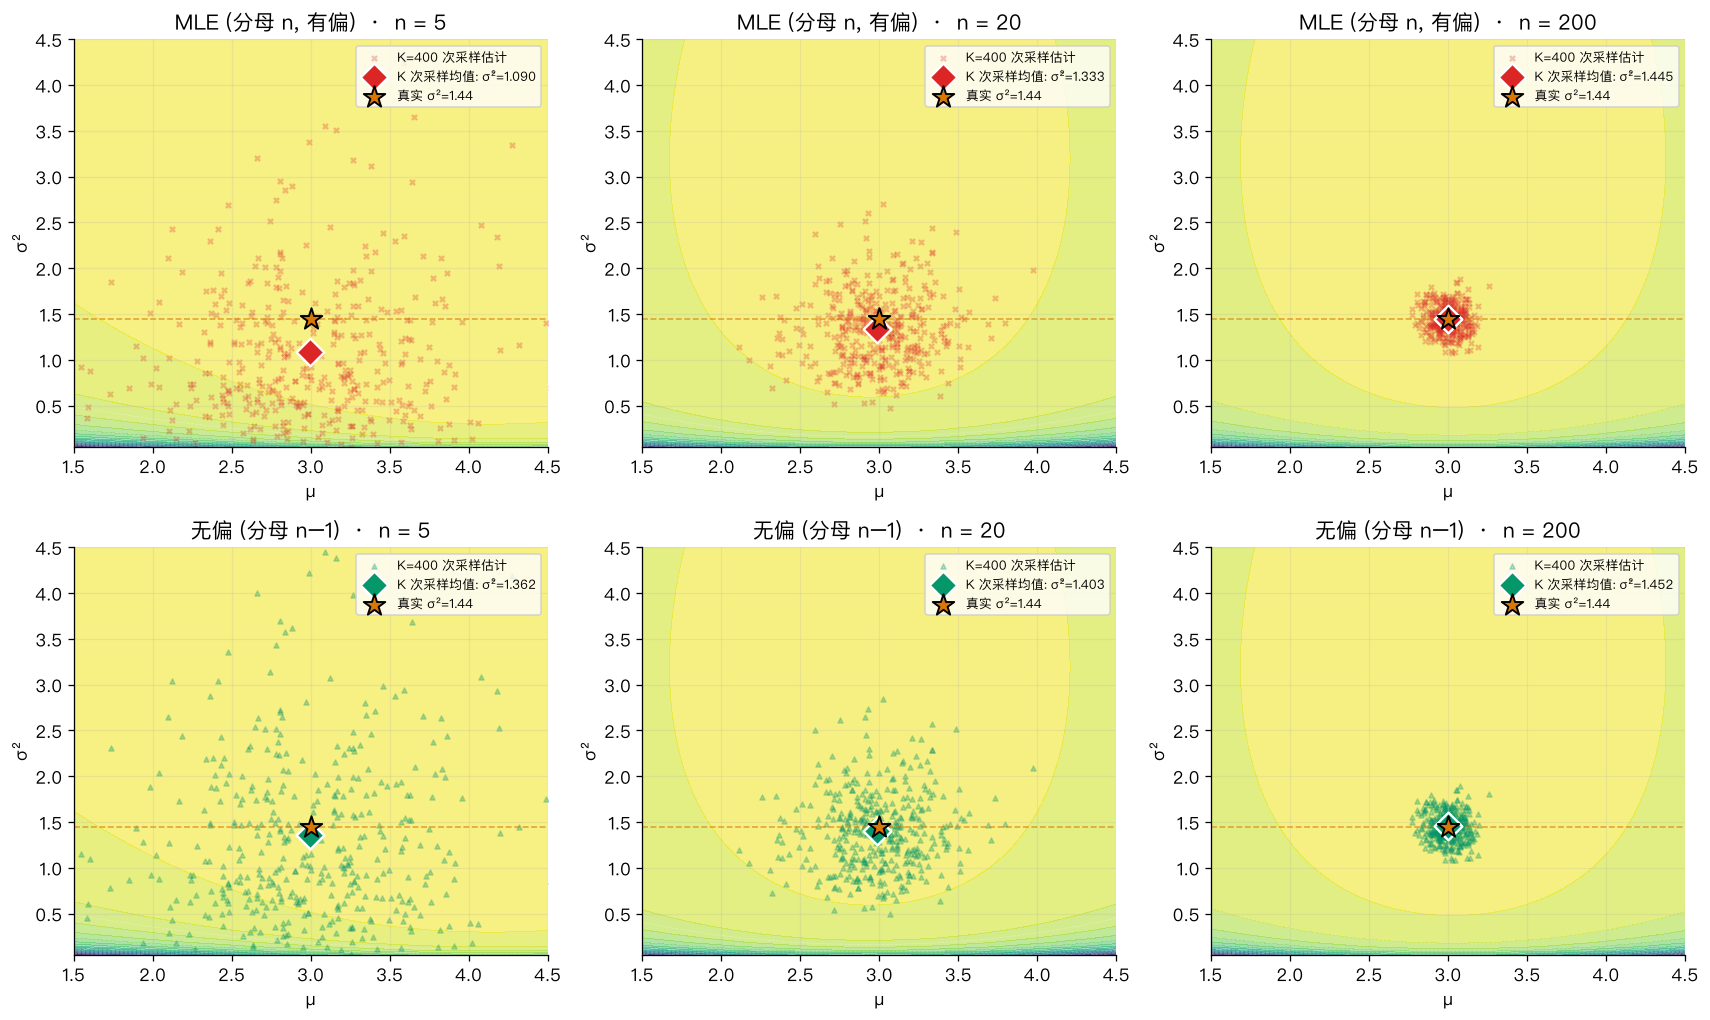

    n |     MLE 均值 |       无偏均值 |       真值 |     MLE 偏差 |       无偏偏差
------------------------------------------------------------------------
    5 |     1.0898 |     1.3622 |   1.4400 |    -0.3502 |    -0.0778
   20 |     1.3327 |     1.4028 |   1.4400 |    -0.1073 |    -0.0372
  200 |     1.4446 |     1.4519 |   1.4400 |    +0.0046 |    +0.0119


In [8]:
# --- 可视化: log-likelihood 曲面 + 多次采样估计点云 ---------------------
def gauss_loglik(mu, sigma2, x):
    n = len(x)
    return -0.5*n*np.log(2*np.pi) - 0.5*n*np.log(sigma2) - 0.5*np.sum((x - mu)**2) / sigma2

def sample_many_estimates(K, n, seed):
    r = np.random.default_rng(seed)
    x_batch = r.normal(3.0, 1.2, size=(K, n))
    mu_hats = x_batch.mean(axis=1)
    sse = ((x_batch - mu_hats[:, None]) ** 2).sum(axis=1)
    return mu_hats, sse / n, sse / (n - 1)

def draw_panel(ax, n_sample, mus, s2_est, est_color, est_marker, label_prefix, x_ref):
    # 背景: 一份典型样本的 log-likelihood 曲面, 作为几何参考
    mu_grid = np.linspace(1.5, 4.5, 100)
    s2_grid = np.linspace(0.05, 4.5, 100)
    Mu, S2 = np.meshgrid(mu_grid, s2_grid)
    LL = np.zeros_like(Mu)
    for i in range(Mu.shape[0]):
        for j in range(Mu.shape[1]):
            LL[i, j] = gauss_loglik(Mu[i, j], S2[i, j], x_ref)
    ax.contourf(Mu, S2, LL, levels=22, cmap="viridis", alpha=0.55)
    ax.contour(Mu, S2, LL, levels=8, colors="white", alpha=0.30, linewidths=0.5)

    # 点云: K 次独立采样得到的 (μ̂, σ̂²)
    ax.scatter(mus, s2_est, color=est_color, marker=est_marker, s=10, alpha=0.28,
               label=f"K={len(mus)} 次采样估计")

    # 均值大菱形 (这一列的关键: MLE 均值明显偏低, 无偏均值贴近真值)
    mean_mu = float(mus.mean()); mean_est = float(s2_est.mean())
    ax.scatter([mean_mu], [mean_est], color=est_color, marker="D", s=150,
               edgecolor="white", linewidth=1.5, zorder=6,
               label=f"K 次采样均值: σ̂²={mean_est:.3f}")

    # 真值
    ax.scatter([3.0], [1.44], color=COLORS["amber"], marker="*", s=200,
               edgecolor="black", linewidth=1.2, zorder=6,
               label="真实 σ²=1.44")
    ax.axhline(1.44, color=COLORS["amber"], linestyle="--", alpha=0.65, lw=1)

    ax.set_xlim(1.5, 4.5); ax.set_ylim(0.05, 4.5)
    ax.set_xlabel("μ"); ax.set_ylabel("σ²")
    ax.set_title(f"{label_prefix}  ·  n = {n_sample}")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.2)

# 用 n=5, 20, 200 拉开差距: n/(n-1) 分别 = 1.25, 1.053, 1.005
K = 400
sample_sizes = [5, 20, 200]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
summary = []
for col, n_sample in enumerate(sample_sizes):
    seed = SEED + n_sample
    mus, s2_mle, s2_unb = sample_many_estimates(K, n_sample, seed)
    # 用一份独立的典型样本画背景 log-likelihood 曲面 (仅作几何参考)
    r_ref = np.random.default_rng(seed + 99999)
    x_ref = r_ref.normal(3.0, 1.2, n_sample)
    draw_panel(axes[0, col], n_sample, mus, s2_mle, COLORS["red"],
               "x", "MLE (分母 n, 有偏)", x_ref)
    draw_panel(axes[1, col], n_sample, mus, s2_unb, COLORS["green"],
               "^", "无偏 (分母 n−1)",    x_ref)
    summary.append((n_sample, s2_mle.mean(), s2_unb.mean()))
plt.tight_layout(); plt.show()

print(f"{'n':>5} | {'MLE 均值':>10} | {'无偏均值':>10} | {'真值':>8} | {'MLE 偏差':>10} | {'无偏偏差':>10}")
print("-" * 72)
for n_sample, mle_mean, unb_mean in summary:
    print(f"{n_sample:>5d} | {mle_mean:>10.4f} | {unb_mean:>10.4f} | "
          f"{1.44:>8.4f} | {mle_mean-1.44:>+10.4f} | {unb_mean-1.44:>+10.4f}")

### 观察

- **上排 MLE 菱形明显在橙色虚线下方** —— 400 次采样的均值都拉不回真值, 就是 MLE 系统性低估 $\sigma^2$ 的直接证据。
- **下排无偏菱形几乎压在橙色虚线上** —— 期望等于真值就是"无偏"的定义在图上的样子。
- **$n$ 越大, 两排菱形都越靠近真值, 点云也越聚拢** —— MLE 的**一致性 (consistency)**: $\hat\theta \xrightarrow{p} \theta_{\text{true}}$。$n=200$ 时肉眼几乎分不出两个菱形的位置差, 这也是为什么深度学习大样本场景里加不加 $n-1$ 修正基本无所谓。

**偏差的精确量**：
$$
\mathbb E[\hat\sigma^2_{\text{MLE}}] - \sigma^2 = -\frac{\sigma^2}{n}
$$
无偏估计通过除以 $n-1$ 把这份 $-\sigma^2/n$ 的偏差恰好补掉。

**直觉**：MLE 用样本均值 $\hat\mu$（**恰好最小化** $\sum(x_i-\mu)^2$ 的那个 $\mu$）代替真 $\mu$，所以残差平方和 $\sum(x_i - \hat\mu)^2 \le \sum(x_i - \mu)^2$。除以 $n$ 直接吞掉这份"最小化 bonus"→ 低估; 除以 $n-1$ 恰好补偿 → 无偏。

## 5 · MLE = 最小化 NLL：深度学习损失函数的真正来源

这一章讲三件事，**你会突然明白为什么 PyTorch 里那些损失函数长成那样**。

### 5.1 Bernoulli MLE ↔ 二元交叉熵 (BCE)

**场景**：二分类任务。每个样本有真实标签 $y_i \in \{0, 1\}$，模型对第 $i$ 个样本输出**它属于正类的预测概率** $\hat p_i \in (0, 1)$（sigmoid 的输出、逻辑回归的输出都是这种形式）。

**Step 1. 概率假设** —— 我们把每个样本看作**一次独立的 Bernoulli 试验**：
$$
y_i \mid \hat p_i \;\sim\; \text{Bernoulli}(\hat p_i)
\quad\Longleftrightarrow\quad
p(y_i \mid \hat p_i) =
\begin{cases}
\hat p_i     & y_i = 1 \\
1 - \hat p_i & y_i = 0
\end{cases}
$$

**Step 2. 用一个式子统一两种情形** —— 上面的 case 分支可以用**指数技巧**合成一行：
$$
p(y_i \mid \hat p_i) = \hat p_i^{\,y_i}(1-\hat p_i)^{1-y_i}
$$
验算：$y_i = 1$ 时 $\hat p_i^{1}(1-\hat p_i)^{0} = \hat p_i$; $y_i = 0$ 时 $\hat p_i^{0}(1-\hat p_i)^{1} = 1 - \hat p_i$。✓

**Step 3. 联合似然 (i.i.d.)** —— 每个样本独立, 全体数据的似然是逐样本相乘：
$$
L(\theta) = \prod_{i=1}^{n} \hat p_i^{\,y_i}(1-\hat p_i)^{1-y_i}
$$
这里 $\theta$ 是模型（比如神经网络）的所有参数, $\hat p_i = f_\theta(x_i)$ 是模型对第 $i$ 个样本给出的预测概率。

**Step 4. 取负对数似然 (NLL)** —— 乘积变加和, 最大化变最小化：
$$
\text{NLL}(\theta) = -\log L(\theta) = -\sum_{i=1}^{n} \big[\, y_i \log \hat p_i + (1-y_i)\log(1-\hat p_i) \,\big]
$$
再除以 $n$ 得到**平均 NLL**, 这个式子和 PyTorch 里 `nn.BCELoss(reduction='mean')` 一字不差：

$$
\boxed{\;\;
\text{BCE}(\theta) = -\frac{1}{n}\sum_{i=1}^{n} \big[\, y_i \log \hat p_i + (1-y_i)\log(1-\hat p_i) \,\big]
\;\;}
$$

**Step 5. 逐样本损失长什么样？** 每个样本对损失的贡献是：
$$
\ell_i =
\begin{cases}
-\log \hat p_i     & y_i = 1 \quad (\text{正类}) \\
-\log(1 - \hat p_i) & y_i = 0 \quad (\text{负类})
\end{cases}
$$

- 正样本 $y_i = 1$: $\hat p_i \to 1$ 时 $\ell_i \to 0$; $\hat p_i \to 0$ 时 $\ell_i \to \infty$。
- 负样本 $y_i = 0$: $\hat p_i \to 0$ 时 $\ell_i \to 0$; $\hat p_i \to 1$ 时 $\ell_i \to \infty$。

**结论**："自信错"的惩罚随 $-\log p$ **无界发散**（$p \to 0$ 时 $-\log p \to \infty$，是**对数式**发散而不是"指数级"）。这就是 BCE 对"高置信错误预测"惩罚特别重的根本原因。

**手算一个例子** —— 3 个样本, $y = (1, 0, 1)$, 预测 $\hat p = (0.9, 0.2, 0.6)$：

$$
\begin{aligned}
\text{BCE}
&= -\tfrac{1}{3}\big[\underbrace{\log 0.9}_{\text{正样本 }y_1=1} + \underbrace{\log(1-0.2)}_{\text{负样本 }y_2=0} + \underbrace{\log 0.6}_{\text{正样本 }y_3=1}\big] \\
&= -\tfrac{1}{3}\big[(-0.1054) + (-0.2231) + (-0.5108)\big] \\
&= -\tfrac{1}{3}\times(-0.8393) \;=\; 0.2798
\end{aligned}
$$

**为什么它叫"交叉熵"** —— 单看一个样本, 真实分布是 one-hot 的 $(y, 1-y)$, 模型分布是 $(\hat p, 1-\hat p)$。两个分布的**交叉熵**定义就是：
$$
H(y, \hat p) = -y\log\hat p - (1-y)\log(1-\hat p)
$$
"Bernoulli 的 NLL" 和"交叉熵"是**同一个式子的两个名字**——一个从统计角度来，一个从信息论角度来。这也是名字里 "cross-entropy" 的来历。

**深度学习里的连接** —— 神经网络输出的 raw logit $z_i$ 会先过 sigmoid 得到 $\hat p_i = \sigma(z_i)$, 再喂给 BCE。工程上为了数值稳定, PyTorch 直接把这两步合成一个 `BCEWithLogitsLoss`, 内部用 $\log(1+e^{-|z|})$ 这类稳定形式, 但**数学上和上面推的完全等价**。

### 5.2 Gaussian MLE (固定 σ) ↔ 均方误差 (MSE)

**场景**：回归任务。给定输入 $x_i$，模型输出一个实数预测 $\hat y_i = f_\theta(x_i)$（比如线性回归的 $w^\top x + b$、神经网络回归头的输出），真实标签 $y_i$ 也是实数。

**Step 1. 概率假设** —— 假设真实值 $y_i$ 是"围绕预测 $\hat y_i$ 的高斯噪声"：
$$
y_i \mid x_i \;\sim\; \mathcal{N}(\hat y_i,\ \sigma^2)
\quad\Longleftrightarrow\quad
p(y_i \mid x_i) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(y_i - \hat y_i)^2}{2\sigma^2}\right)
$$

$\sigma$ 是"我们相信数据里有多大噪声"这个常数, **不随预测变化**。这一条假设看似平常, 却直接决定了下面损失函数会长成 MSE 而不是 MAE 或 Huber。

**Step 2. 联合似然 (i.i.d.)**
$$
L(\theta) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(y_i - \hat y_i)^2}{2\sigma^2}\right)
$$

**Step 3. 取对数, 拆分成常数 + 二次项**（推导思路与第 4 章 Gaussian MLE 相同）：
$$
\ell(\theta) = -\frac{n}{2}\log(2\pi\sigma^2) \;-\; \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \hat y_i)^2
$$

**Step 4. 取负号得到 NLL, 并把与 $\theta$ 无关的项打包到常数**：
$$
\text{NLL}(\theta) = \underbrace{\frac{n}{2}\log(2\pi\sigma^2)}_{\text{与 }\theta\text{ 无关, 常数}}
\;+\; \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \hat y_i)^2
$$

**Step 5. 关键一步：$\sigma$ 已固定, $\tfrac{1}{2\sigma^2}$ 是**正的常数**, 对 argmin 没有影响。所以：
$$
\arg\min_\theta \text{NLL}(\theta) \;=\; \arg\min_\theta \sum_{i=1}^{n} (y_i - \hat y_i)^2
\;=\; \arg\min_\theta \underbrace{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat y_i)^2}_{\text{MSE}}
$$

$$
\boxed{\;\;
\text{MSE}(\theta) = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat y_i)^2
\;\;}
$$

**换句话说**：**MSE 不是拍脑袋写的一个"平方误差"损失, 而是"假设标签服从固定方差高斯噪声"这条概率假设下的 MLE**。这就是为什么线性回归 = 最小二乘 = Gaussian MLE, 三种说法本质是同一件事 (Gauss 1809 就是这样把最小二乘和正态分布挂钩的)。

**Step 6. 一个小手算** — 3 个样本, 真值 $y = (2.0, 3.0, 5.0)$, 预测 $\hat y = (2.5, 2.8, 4.7)$:
$$
\begin{aligned}
\text{MSE}
&= \tfrac{1}{3}\big[(2.0 - 2.5)^2 + (3.0 - 2.8)^2 + (5.0 - 4.7)^2\big] \\
&= \tfrac{1}{3}\big[0.25 + 0.04 + 0.09\big] \\
&= \tfrac{0.38}{3} \approx 0.1267
\end{aligned}
$$

**Step 7. 深挖：如果 σ 也让模型学呢？**

上面 $\sigma$ 是常数, 所以它变成 MSE。**但如果我们让模型对每个 $x_i$ 也预测方差 $\hat\sigma_i^2$**（叫**异方差 (heteroscedastic) 回归** / **概率回归**）, NLL 就多了一项 $\log \hat\sigma_i^2$：

$$
\text{NLL}(\theta) = \frac{1}{2}\sum_i \left[\frac{(y_i - \hat y_i)^2}{\hat\sigma_i^2} + \log \hat\sigma_i^2\right] + \text{const}
$$

物理意义:
- 第一项 = **加权 MSE**, 权重是 $1/\hat\sigma_i^2$。模型对哪个样本越自信 (方差越小), 那个样本的残差就越被惩罚。
- 第二项 = **对过大方差的惩罚**。防止模型偷懒——只要 $\hat\sigma_i \to \infty$, 第一项就能被无限压小, 所以必须加 $\log \hat\sigma_i^2$ 让"预测很大方差"付出代价。

**结论**: MSE 是 Gaussian NLL 在"方差固定"这个特例下的样子; 一旦让方差可学, 就自动得到贝叶斯统计里常见的 "Gaussian NLL loss"。PyTorch 里对应 `nn.GaussianNLLLoss`。

**Step 8. 为什么不是 MAE / Huber ?**

换一个噪声假设, 损失就换一副面孔:

| 概率假设 $p(y_i \mid \hat y_i)$ | 对应损失 (逐样本) | PyTorch 名字 |
|---------------------------------|--------------------|--------------|
| Gaussian $\mathcal N(\hat y_i, \sigma^2)$ | $(y_i - \hat y_i)^2$ | `MSELoss` |
| Laplace  $\text{Lap}(\hat y_i, b)$        | $\|y_i - \hat y_i\|$ | `L1Loss` (MAE) |
| Student-t (重尾)                          | $\log(1 + \tfrac{(y_i-\hat y_i)^2}{\nu})$ | (无内置, 但常见于抗噪回归) |
| Huber 型误差分布 $p(e)\propto e^{-\operatorname{Huber}(e)}$ | Huber / Smooth L1 | `HuberLoss` / `SmoothL1Loss` |

**记忆口诀**: **"选什么损失, 就是在选你相信标签噪声长什么样。"** MSE 隐含"噪声是薄尾对称的高斯", 所以对离群点非常敏感 (二次惩罚); MAE 隐含"噪声是重尾的 Laplace", 所以对离群点鲁棒; Huber 在小残差区使用二次惩罚、在大残差区使用线性惩罚，对应中心近似 Gaussian、尾部近似 Laplace 的 **Huber 型分布**，但它不是简单的 Gaussian 与 Laplace 混合分布。

### 5.3 Categorical MLE ↔ 交叉熵 (CE)

**场景**：$K$ 分类任务。每个样本有真实类别 $y_i \in \{1, \dots, K\}$，模型对第 $i$ 个样本输出一个**长度为 $K$ 的概率向量** $\hat{\mathbf p}_i = (\hat p_{i,1}, \dots, \hat p_{i,K})$, 满足 $\sum_c \hat p_{i,c} = 1$。这通常由神经网络先输出 $K$ 个 logit $\mathbf z_i$, 再过 softmax 得到:
$$
\hat p_{i,c} = \frac{\exp(z_{i,c})}{\sum_{k=1}^{K} \exp(z_{i,k})}
$$

**Step 1. 概率假设** —— 单个样本的类别服从 **Categorical (类别) 分布**, 参数就是模型输出的 $\hat{\mathbf p}_i$：
$$
y_i \mid \hat{\mathbf p}_i \;\sim\; \text{Categorical}(\hat{\mathbf p}_i)
\quad\Longleftrightarrow\quad
p(y_i = c \mid \hat{\mathbf p}_i) = \hat p_{i,c}
$$

**Step 2. 用 one-hot 统一 K 种情形** —— 类似 5.1 里的指数技巧, 但换成"K 个指数相乘"。把真实类别 $y_i$ 转为 one-hot 向量 $\mathbf t_i \in \{0,1\}^K$（$t_{i,c} = 1$ 当且仅当 $c$ 是真实类别）:
$$
p(y_i \mid \hat{\mathbf p}_i) = \prod_{c=1}^{K} \hat p_{i,c}^{\,t_{i,c}}
$$
因为 $\mathbf t_i$ 只有一个位置是 1、其它全 0, 这个连乘里**只有真实类别那一项存活**, 其他项都是 $\hat p^{0} = 1$。所以它等价于 $\hat p_{i, y_i}$——**看起来复杂, 本质是"挑出真实类别对应的那个预测概率"**。

**Step 3. 联合似然 (i.i.d.)**
$$
L(\theta) = \prod_{i=1}^{n} \prod_{c=1}^{K} \hat p_{i,c}^{\,t_{i,c}}
$$

**Step 4. 取负对数似然**
$$
\text{NLL}(\theta)
= -\sum_{i=1}^{n} \sum_{c=1}^{K} t_{i,c} \log \hat p_{i,c}
= -\sum_{i=1}^{n} \log \hat p_{i,\, y_i}
$$

两种写法**完全等价**, 只是视角不同：
- **左式 (显式 one-hot)** —— 逐样本、逐类别求和。适合推导, 也适合 **label smoothing / 知识蒸馏** 这类"标签不是 one-hot 而是软分布"的场景。
- **右式 (只挑真实类别)** —— 因为 one-hot 让求和塌陷成一项。PyTorch 的 `nn.NLLLoss` 内部就是这样, 只用 `log_softmax` 输出对应真实类别的那一个数, 不做求和。

除以 $n$ 得到平均交叉熵损失, 对应 `nn.CrossEntropyLoss(reduction='mean')`:
$$
\boxed{\;\;
\text{CE}(\theta) = -\frac{1}{n}\sum_{i=1}^{n} \log \hat p_{i,\, y_i}
= -\frac{1}{n}\sum_{i=1}^{n} \sum_{c=1}^{K} t_{i,c} \log \hat p_{i,c}
\;\;}
$$

**Step 5. 向量化视角：CE 就是两个分布的负点积**

对第 $i$ 个样本, 真实分布向量是 one-hot $\mathbf t_i$, 预测分布向量是 $\hat{\mathbf p}_i$。逐样本交叉熵可以写成：
$$
H(\mathbf t_i, \hat{\mathbf p}_i) = -\mathbf t_i \cdot \log \hat{\mathbf p}_i = -\sum_c t_{i,c} \log \hat p_{i,c}
$$
这是**两个概率向量之间的负内积（对预测取 log 之后）**——5.1 的 BCE 就是这个式子在 $K=2$ 时的展开形式，只是当时把两维写成 $(y, 1-y)$。

交叉熵和 KL 散度不是“集合包含”关系，而满足：
$$
H(P,Q) = H(P) + D_{\mathrm{KL}}(P\|Q)
$$
训练数据决定的真实分布 $P$ 固定时，$H(P)$ 与模型参数无关，因此**最小化交叉熵等价于最小化 $D_{\mathrm{KL}}(P\|Q)$**。

**Step 6. 手算例子** —— 3 类分类, 真实类别 $y = 2$ (类别索引从 1 起), 模型 softmax 输出 $\hat{\mathbf p} = (0.1, 0.7, 0.2)$：

$$
\text{CE}_{\text{one sample}}
= -\log \hat p_{y=2}
= -\log 0.7
= 0.3567
$$

对比同一个样本, 若预测很自信但错了 $\hat{\mathbf p} = (0.8, 0.15, 0.05)$：
$$
\text{CE} = -\log 0.15 = 1.897
$$
以及完全自信错 $\hat{\mathbf p} = (0.99, 0.005, 0.005)$：
$$
\text{CE} = -\log 0.005 = 5.298
$$

**结论**: 只有"分给真实类别的概率"直接进入 loss；其它类别仍会通过 softmax 的归一化共同影响这个概率。**"自信错"** 的损失是 $-\log(\text{小概率}) \to \infty$，因此会受到很重的惩罚。与 sigmoid/softmax 配合时，CE 通常比“概率输出 + MSE”更不容易在错误且饱和的区域丢失有效梯度，但实际收敛速度仍取决于模型、初始化、优化器和数据，不能无条件断言一定更快。

**Step 7. 与 softmax 的深度耦合**

数学上, 神经网络先输出 raw logits $\mathbf z_i$, 再过 softmax 得到 $\hat{\mathbf p}_i$。把两步代入 CE:

$$
-\log \hat p_{i, y_i} = -\log \frac{\exp(z_{i, y_i})}{\sum_k \exp(z_{i, k})} = -z_{i, y_i} + \log\!\sum_k \exp(z_{i, k})
$$

后面这个 $\log\sum\exp$ 就是著名的 **LogSumExp**, 数值上很稳定 (可以减去 $\max z$ 做归一化), 完全避免中间的 exp / 除法。PyTorch 里 `nn.CrossEntropyLoss` **直接吃 logits, 不接受 softmax 输出**——就是把这两步合并成一个数值稳定的算子。经验教训：**不要在网络最后加 softmax 再用 CE, 会被算两遍且数值不稳。**

---

**下面 Step 8-9 是进阶阅读**（👉 第一遍读只想理解 "CE = Categorical MLE" 可以直接跳到 5.4）。这两步展示 CE 在深度学习工程里的两个"美妙副作用": 梯度形式 + 软标签推广。

**Step 8. 梯度极简**（进阶）

CE + softmax 有一个非常漂亮的梯度 —— 对 logit $z_{i,c}$ 求导:
$$
\frac{\partial\, \text{CE}}{\partial z_{i,c}} = \hat p_{i,c} - t_{i,c}
$$
"预测概率 − 真实 one-hot"就是**对 logit 的梯度**，结构和 5.2 的 MSE 对预测值的梯度 $\hat y-y$ 同形。这里必须区分求导对象：

- 对真实类别概率 $p_y$ 求导：$\partial(-\log p_y)/\partial p_y=-1/p_y$，当 $p_y\to0$ 时会发散。
- 对 softmax 前的 logit $z_c$ 求导：$\partial\text{CE}/\partial z_c=p_c-t_c\in[-1,1]$，梯度有界。

softmax 的链式求导把前者化简成后者，这正是工程上直接使用 logits + `CrossEntropyLoss` 的重要原因。

**Step 9. 从 one-hot 到软标签**（进阶）

如果我们把 one-hot $\mathbf t_i$ 换成任意概率向量 $\mathbf q_i$（每个位置都可以是小数）, CE 立刻推广到 **soft-target 训练**:

- **Label smoothing** —— 把 $\mathbf t_i$ 从 $(0,\dots,1,\dots,0)$ 平滑成 $((1-\varepsilon)/K + \varepsilon)_{y_i}, \varepsilon/K$ 均匀撒到其他类。防止模型对训练标签过度自信。
- **知识蒸馏 (KD)** —— 把 $\mathbf q_i$ 换成"老师网络"输出的软概率, 学生学的是老师的"暗知识"（哪些错误类别更相似）。
- **Mixup / CutMix** —— 训练样本本身是两个样本的凸组合, 目标也是两个 one-hot 的凸组合。

数学上**式子完全不变**, 只是 one-hot 求和"塌陷成一项"这个化简不成立了, 必须走 **Step 4 的显式求和版本**。这就是为什么 PyTorch 里 label smoothing 参数 `CrossEntropyLoss(label_smoothing=0.1)` 内部走的是"全类别求和 log_softmax"的路径。

**总结**：损失函数不是从天上掉下来的，是你**假设了什么概率分布，就得到什么损失**。

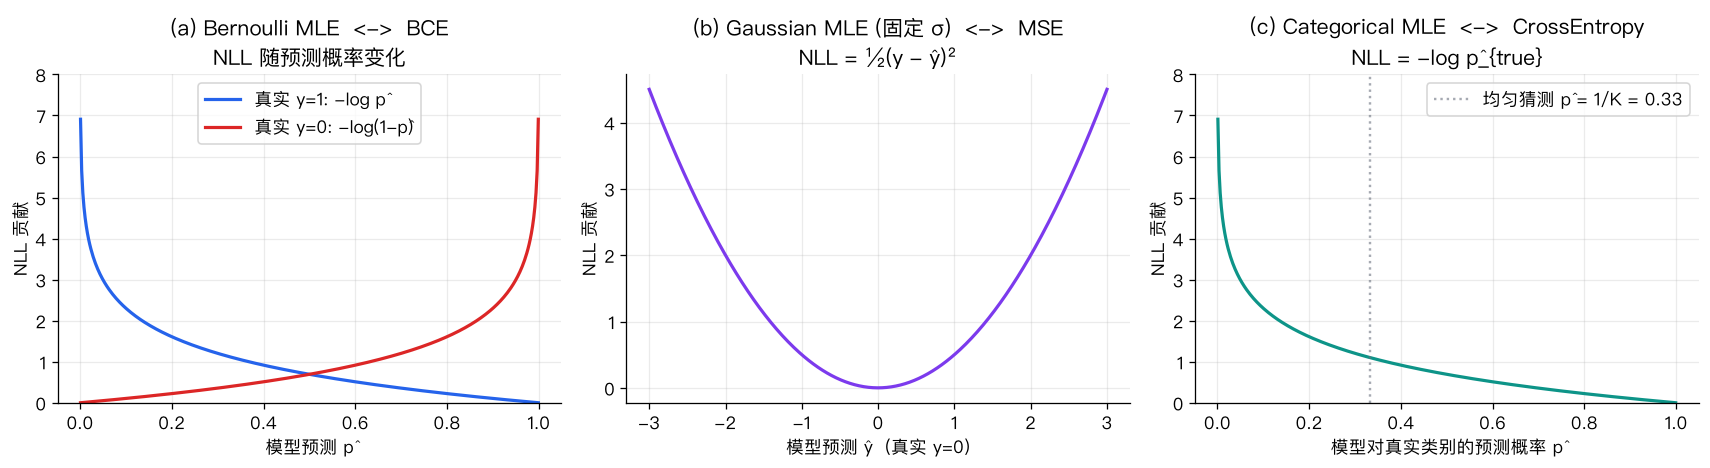

In [9]:
# --- 三条 NLL 曲线, 让"损失长什么样"变得直观 ---------------------------
p_hat = np.linspace(0.001, 0.999, 400)

# (a) Bernoulli: 假设真实标签 y=1, 观察 -log p_hat 随 p_hat 变化
nll_bce_pos = -np.log(p_hat)          # y=1 情形
nll_bce_neg = -np.log(1 - p_hat)      # y=0 情形

# (b) Gaussian: 假设真实 y=0, 预测 y_hat 变化, σ=1
y_hat = np.linspace(-3, 3, 400)
nll_mse = 0.5 * (0.0 - y_hat) ** 2   # 常数项忽略

# (c) Categorical: 3 类, 真实类别 = 0, 预测其他两类各占 (1-p)/2
K = 3
nll_ce = -np.log(p_hat)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(p_hat, nll_bce_pos, color=COLORS["blue"], lw=2, label="真实 y=1: -log p̂")
axes[0].plot(p_hat, nll_bce_neg, color=COLORS["red"],  lw=2, label="真实 y=0: -log(1-p̂)")
axes[0].set_title("(a) Bernoulli MLE  <->  BCE\nNLL 随预测概率变化")
axes[0].set_xlabel("模型预测 p̂"); axes[0].set_ylabel("NLL 贡献")
axes[0].set_ylim(0, 8); axes[0].legend()

axes[1].plot(y_hat, nll_mse, color=COLORS["purple"], lw=2)
axes[1].set_title("(b) Gaussian MLE (固定 σ)  <->  MSE\nNLL = ½(y - ŷ)²")
axes[1].set_xlabel("模型预测 ŷ  (真实 y=0)"); axes[1].set_ylabel("NLL 贡献")

axes[2].plot(p_hat, nll_ce, color=COLORS["teal"], lw=2)
axes[2].axvline(1/K, color=COLORS["gray"], linestyle=":", alpha=0.6,
                label=f"均匀猜测 p̂ = 1/K = {1/K:.2f}")
axes[2].set_title("(c) Categorical MLE  <->  CrossEntropy\nNLL = -log p̂_{true}")
axes[2].set_xlabel("模型对真实类别的预测概率 p̂"); axes[2].set_ylabel("NLL 贡献")
axes[2].set_ylim(0, 8); axes[2].legend()

plt.tight_layout(); plt.show()

### 5.4 三张 loss 曲线怎么读

三张图纵轴都是**逐样本贡献的 NLL**（不是数据集总 loss），横轴含义各不相同。放在一起看，能一眼看出"损失函数长什么样，是概率假设的直接后果"。

#### (a) Bernoulli / BCE — 两条对称的对数发散曲线

- **横轴**: 模型输出的预测概率 $\hat p$（0~1）；**两条曲线**分别对应"真实标签 $y=1$"和"$y=0$"两种情形。
- 正样本蓝线 $\ell = -\log \hat p$：预测越接近 1 损失越小，越接近 0 (**判正为负**) 损失飙到无穷。
- 负样本红线 $\ell = -\log(1-\hat p)$：完全镜像。
- 两条线在 $\hat p = 0.5$ 相交，$-\log 0.5 = 0.693$ —— **二分类"完全不知所措"的基线损失**。
- 关键形状: **对数级发散**。这就是为什么 BCE 对"极度自信错误 ($\hat p = 0.99$ 但真值 0)"给出巨大梯度。

#### (b) Gaussian / MSE — 一条对称抛物线

- **横轴**: 模型预测的实数值 $\hat y$，假设真值 $y=0$；曲线 $\ell = \tfrac12 (y - \hat y)^2$。
- 底在 $\hat y = 0$ (预测=真值) 时损失为 0，**左右完全对称**——这是"高斯噪声对称"这条概率假设的直接后果。
- 偏离 $\pm 1$ 损失 = 0.5，偏离 $\pm 2$ 损失 = 2，偏离 $\pm 3$ 损失 = 4.5。**误差每翻倍, 损失变 4 倍。**
- 关键形状: **二次增长**。所以 **MSE 对离群点非常敏感**——1 个偏离 10 的点损失 = 50, 压过 100 个偏离 1 的点。

#### (c) Categorical / CE — 和 BCE 蓝线同形, 多一条基线

- **横轴**: 模型对**真实类别**的预测概率 $\hat p_{\text{true}}$；曲线 $\ell = -\log \hat p_{\text{true}}$。
- 曲线形状和 (a) 蓝线**一模一样**——因为多分类 CE 就是"挑出真实类别的概率取 log"，one-hot 让求和塌陷成一项 (5.3 Step 4)。
- **灰色竖虚线在 $\hat p = 1/K$** 处，对应 $-\log(1/K)$。图中 $K=3$，虚线在 0.33 处，$-\log(1/3) \approx 1.099$ —— **"完全随机猜"的基线 loss**。
- **一秒钟诊断技巧**: 训练早期 loss 应该在 $\log K$ 附近, 收敛后应显著低于它。
  - 2 分类基线 = $\log 2 \approx 0.693$
  - 3 分类基线 = $\log 3 \approx 1.099$
  - 10 分类基线 = $\log 10 \approx 2.303$
  - 1000 分类基线 = $\log 1000 \approx 6.908$
  - **如果 3 分类训了半天 loss 还在 1.1, 说明模型和瞎猜差不多。**

### 三张图小结

| 图 | 横轴物理含义 | 曲线形状 | 隐含概率假设 | 对离群点/自信错的敏感度 |
|----|--------------|----------|--------------|-------------------------|
| (a) | 预测"是正类"的概率 | $-\log$ 对数发散 | Bernoulli | 自信错 → loss 很大；对概率梯度发散、对 logit 梯度有界 |
| (b) | 预测的实数值 | 二次抛物线 | Gaussian, σ 固定 | 离群残差 → 二次膨胀 |
| (c) | 预测"是真实类别"的概率 | $-\log$ 对数发散 | Categorical | 与 (a) 完全同形, K=2 时退化为 BCE |

**一句话核心**：**损失函数长什么样, 完全由概率假设决定**。你不是在"选损失"，是在"选噪声 / 输出分布模型"，损失只是它的负对数似然。BCE 和 CE 曲线同形并非巧合——BCE 就是 $K=2$ 的 CE；只有 MSE 是二次形状，因为高斯密度的指数上是平方。

### 实战提醒: 判断模型是否在学东西

三张图纵轴都是**逐样本贡献**，训练时打印的 loss 是 batch 平均或 sum，量级不同但形状不变。所以在训练监控面板上：

- **分类** (BCE / CE): 有明确的**瞎猜基线** $\log K$。loss 显著低于它说明学到了信号，接近 0 要警惕过拟合。
- **回归** (MSE): **没有绝对基线**，因为它依赖数据量纲 (单位是元 / 米 / 秒都会让 loss 数值差万倍)。一般看**决定系数 R²** 或者**loss 和标签方差 σ² 的比值** 来判断。

## 5.5 一个记忆口诀

> **"MLE 是原理, 损失函数是它戴上具体分布假设后的样子。"**

| 你假设的模型 | MLE 派生出的损失 | PyTorch 名字 |
|--------------|------------------|--------------|
| $y \sim \text{Bernoulli}(\hat p)$ | $-[y\log \hat p + (1-y)\log(1-\hat p)]$ | `BCELoss` |
| $y \sim \mathcal{N}(\hat y, \sigma^2)$, $\sigma$ 常数 | $(y - \hat y)^2$ | `MSELoss` |
| $y \sim \text{Categorical}(\hat{\mathbf p})$ | $-\log \hat p_{y}$ | `CrossEntropyLoss` / `NLLLoss` |
| $y \sim \mathcal{N}(\hat y, \hat \sigma^2)$, 都学 | 一半 MSE + 一半 $\log \hat\sigma^2$ | 高斯 NLL, 常用于概率回归 |
| $y \sim \text{Laplace}(\hat y, b)$ | $|y - \hat y|$ | `L1Loss` (MAE) |
| $y \sim \text{Poisson}(\hat\lambda)$ | $\hat\lambda - y \log \hat\lambda$ | `PoissonNLLLoss` |

**这就是为什么调 loss 常常等价于换概率假设。**

## 6 · 数值 MLE：没有闭式解怎么办

### 6.1 铺垫：什么叫"闭式解"

回顾第 3、4 章我们做的事：

1. 写下对数似然 $\ell(\theta)$。
2. 对 $\theta$ **求导**、**令导数 = 0**。
3. **代数移项** 直接把 $\hat\theta$ 解出来。

Bernoulli 得到 $\hat\theta = k/n$，Gaussian 得到 $\hat\mu = \bar x$、$\hat\sigma^2 = \tfrac1n\sum(x_i-\bar x)^2$。这种能"用一个公式一步写出答案"的解叫**闭式解 / 解析解 (closed-form solution)**。

**这是特例, 不是常态。** 之所以能解, 是因为 Bernoulli 和 Gaussian 的 log-likelihood 形式非常简单——求导后剩下的方程线性可解。大多数真实模型没有这种运气。

### 6.2 什么样的模型没有闭式解？

只要 log-likelihood 的导数方程**代数上解不出 $\hat\theta$**，就没有闭式解。常见的几类：

| 模型 | 卡在哪里 |
|------|----------|
| 逻辑回归 | 导数里含 $\sigma(w^\top x)$（sigmoid），移项后是超越方程 |
| 神经网络 | 参数上百万个，$\ell$ 是极高维非线性函数 |
| 混合高斯 GMM | log 里嵌套着加和 $\log\sum_k \pi_k \mathcal N(\ldots)$，求导无法整理 |
| Cauchy 位置参数 | 求导后是有理式，代数上无根式解 |

**遇到这些情况怎么办？** —— **数值优化**：从一个初始猜测 $\theta_0$ 出发, 让计算机一步步"往山谷底走", 直到再往哪走都会升上去为止。这就是"数值 MLE"。**深度学习框架里的 `loss.backward() + optimizer.step()` 循环, 本质就是在做这件事**。

### 6.3 数值 MLE 的三步套路（对任何模型都一样）

```
   ┌───────────────────────────────────────────────┐
   │ 第 1 步：写 log-likelihood                     │
   │         ℓ(θ) = Σᵢ log p(xᵢ | θ)                 │
   ├───────────────────────────────────────────────┤
   │ 第 2 步：取负号得 NLL                          │
   │         f(θ) = -ℓ(θ)                            │
   │         (变成最小化问题, 统一接口)              │
   ├───────────────────────────────────────────────┤
   │ 第 3 步：从初值 θ₀ 出发调用优化器下山           │
   │         scipy.optimize.minimize(f, θ₀)         │
   │         (SGD / Adam / L-BFGS 都行)              │
   └───────────────────────────────────────────────┘
```

下面**先在一个我们会手算的场景 (Bernoulli) 上跑一遍这三步**, 验证数值方法能得到和手算相同的答案；再看什么时候数值优化会踩坑。

手算闭式解 θ̂ = k/n = 7/10 = 0.7
数值优化 θ̂          = 0.700000
两者差距           = 7.74e-09


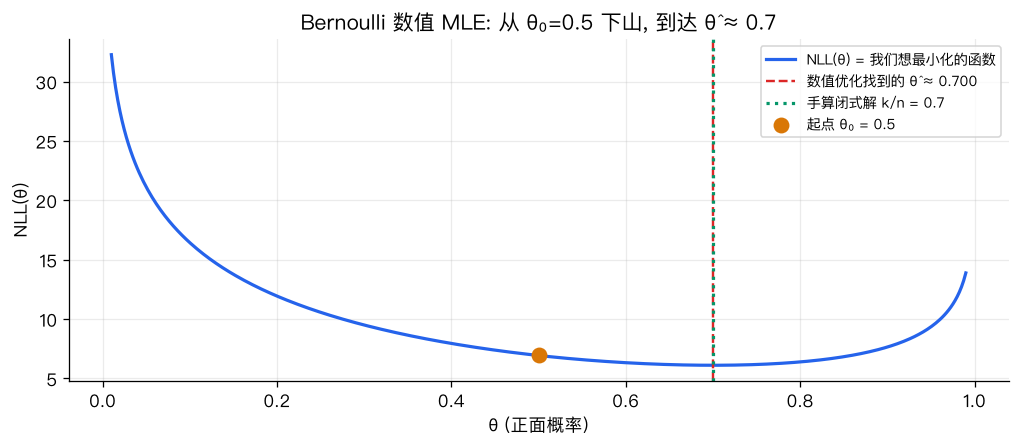

In [10]:
# --- 6.4 热身: Bernoulli 的数值 MLE ------------------------------------
n_flips = 10
k_heads = 7

# 第 1 步: log-likelihood  ℓ(θ) = k log θ + (n-k) log(1-θ)
def bernoulli_loglik(theta, n, k):
    return k * np.log(theta) + (n - k) * np.log(1 - theta)

# 第 2 步: NLL = -log-likelihood
def bernoulli_nll(theta_vec, n, k):
    # scipy.minimize 的输入是数组, 所以 theta_vec = [θ]
    return -bernoulli_loglik(theta_vec[0], n, k)

# 第 3 步: 从初值出发调用优化器
theta0 = 0.5   # 起点: 假装完全不知道答案, 从"最中性"的 0.5 开始
res = optimize.minimize(
    bernoulli_nll,
    x0=[theta0],
    args=(n_flips, k_heads),
    bounds=[(1e-6, 1 - 1e-6)],   # θ ∈ (0, 1), 加安全边距避免 log(0)
    method="L-BFGS-B",
)
theta_hat_numeric = res.x[0]
theta_hat_closed_form = k_heads / n_flips

print(f"手算闭式解 θ̂ = k/n = {k_heads}/{n_flips} = {theta_hat_closed_form}")
print(f"数值优化 θ̂          = {theta_hat_numeric:.6f}")
print(f"两者差距           = {abs(theta_hat_numeric - theta_hat_closed_form):.2e}")
assert res.success, res.message
assert np.isclose(theta_hat_numeric, theta_hat_closed_form, atol=1e-5)

# 画 NLL 曲线 + 起点 + 优化终点
thetas = np.linspace(0.01, 0.99, 400)
nll_curve = -bernoulli_loglik(thetas, n_flips, k_heads)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thetas, nll_curve, color=COLORS["blue"], lw=2, label="NLL(θ) = 我们想最小化的函数")
ax.axvline(theta_hat_numeric, color=COLORS["red"], linestyle="--",
           label=f"数值优化找到的 θ̂ ≈ {theta_hat_numeric:.3f}")
ax.axvline(k_heads/n_flips, color=COLORS["green"], linestyle=":", lw=2,
           label=f"手算闭式解 k/n = {k_heads/n_flips}")
ax.scatter([theta0], [-bernoulli_loglik(theta0, n_flips, k_heads)],
           color=COLORS["amber"], s=80, zorder=5, label=f"起点 θ₀ = {theta0}")
ax.set_xlabel("θ (正面概率)")
ax.set_ylabel("NLL(θ)")
ax.set_title("Bernoulli 数值 MLE: 从 θ₀=0.5 下山, 到达 θ̂ ≈ 0.7")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 6.5 观察: 数值方法和手算完全一致

- **蓝色曲线**是 NLL, 目标是找它的**最低点**。
- **黄点** = 起始猜测 $\theta_0 = 0.5$。
- **红色虚线** = 优化器一步步下山最后停下的位置 (数值 MLE)。
- **绿色点线** = 第 3 章手算的闭式解 $k/n = 0.7$。
- **两条竖线完全重合** —— 数值方法找到的 $\hat\theta$ 和手算答案精度差 $\sim 10^{-8}$, 等价。

**关键洞察**：数值 MLE 不是"闭式解的替代品", 而是**同一个思想的通用实现**。不管模型多复杂, 只要能写出 log-likelihood, 就能用同一个 `optimize.minimize` 接口求 MLE。**深度学习的整个训练过程就是在做这件事**, 只是参数不是一个 $\theta$ 而是几百万个。

这条流水线对**所有** MLE 问题都一样：`写 ℓ → 取负得 NLL → 从 θ₀ 出发调用优化器 → 得到 θ̂`。

那什么时候会踩坑？下面看一个"外表看似简单, 实际非常麻烦"的例子。

### 6.6 进阶：非凸 NLL —— 一个会踩坑的例子

上一节 Bernoulli 的 NLL 长成一个漂亮的碗——无论从哪里出发都会滚到同一个最低点。这种函数叫**凸函数 (convex)**。**凸问题很好办**：数值优化不管从哪里出发都能找到全局最优。

**但很多真实模型的 NLL 是"非凸的"**：像一个高低起伏的山谷群, 有多个"坑"。从某个坑里下山, 只会停在**这个坑的底部**, 找不到别的坑。这就叫**局部极值 (local minimum) 陷阱**。

用一个 1 维小例子演示：**Cauchy 分布的位置参数 MLE**。

**Cauchy 分布是什么？** —— 简单说, 就是"高斯分布的重尾表兄"。形状也是钟形对称, 但尾巴衰减得慢得多, 容易出现离群点。它的 PDF (概率密度函数):

$$
p(x \mid \mu, \gamma) = \frac{1}{\pi \gamma \left[1 + \left(\dfrac{x-\mu}{\gamma}\right)^2\right]}
$$

其中 $\mu$ 是**位置参数** (钟形的中心), $\gamma > 0$ 是**尺度参数** (控制钟形的宽度, 越大分布越"胖")。本节为简化演示取 $\gamma = 1$, 此时公式化简为 $p(x \mid \mu) = \dfrac{1}{\pi\big(1 + (x-\mu)^2\big)}$。**Cauchy 的 MLE 没有闭式解**——这正是选它举例的原因。下面把 Cauchy 和 Gaussian 画在一起, 直观感受一下"重尾"是什么意思。

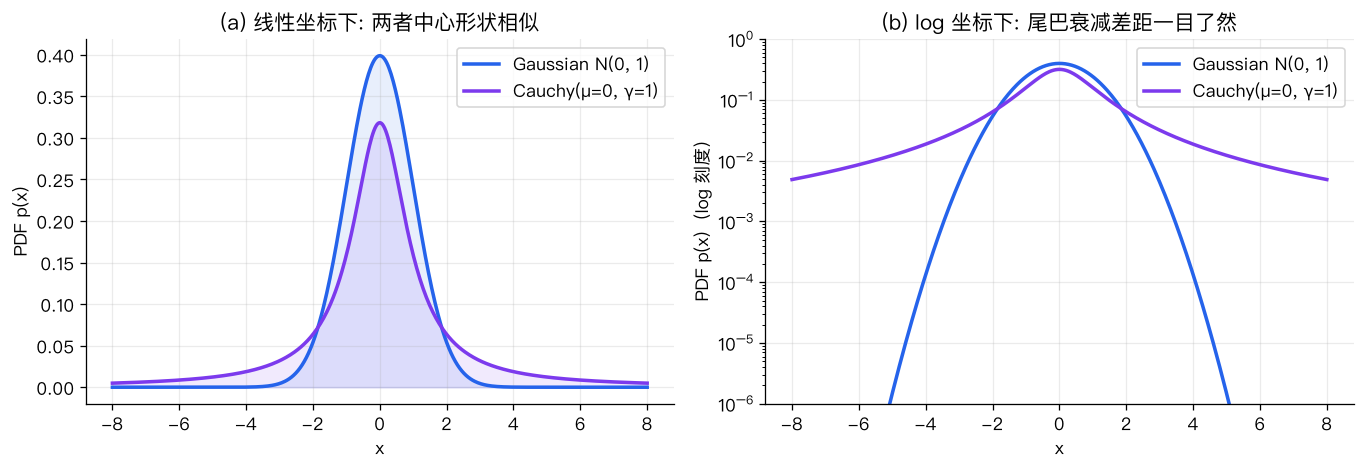

P(|x| > 3):
  Gaussian N(0, 1) : 0.002700   (约 0.27%)
  Cauchy(0, 1)     : 0.204833   (约 20.48%)
  倍数比值        : Cauchy 尾巴概率 ≈ 76× Gaussian


In [11]:
# --- Cauchy vs Gaussian: 直观对比"重尾" ---------------------------------
xs = np.linspace(-8, 8, 500)
cauchy_pdf = stats.cauchy.pdf(xs, loc=0, scale=1)
gauss_pdf  = stats.norm.pdf(xs, loc=0, scale=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) 线性坐标: 看整体形状
ax = axes[0]
ax.plot(xs, gauss_pdf,  color=COLORS["blue"],   lw=2.2, label="Gaussian N(0, 1)")
ax.plot(xs, cauchy_pdf, color=COLORS["purple"], lw=2.2, label="Cauchy(μ=0, γ=1)")
ax.fill_between(xs, 0, cauchy_pdf, alpha=0.10, color=COLORS["purple"])
ax.fill_between(xs, 0, gauss_pdf,  alpha=0.10, color=COLORS["blue"])
ax.set_title("(a) 线性坐标下: 两者中心形状相似")
ax.set_xlabel("x"); ax.set_ylabel("PDF p(x)")
ax.legend()

# (b) log 坐标: 让尾巴的衰减速度可见
ax = axes[1]
ax.plot(xs, gauss_pdf,  color=COLORS["blue"],   lw=2.2, label="Gaussian N(0, 1)")
ax.plot(xs, cauchy_pdf, color=COLORS["purple"], lw=2.2, label="Cauchy(μ=0, γ=1)")
ax.set_yscale("log")
ax.set_ylim(1e-6, 1)
ax.set_title("(b) log 坐标下: 尾巴衰减差距一目了然")
ax.set_xlabel("x"); ax.set_ylabel("PDF p(x)  (log 刻度)")
ax.legend()

plt.tight_layout(); plt.show()

# 数字对比: 落在 ±3 之外 (离中心 > 3 个尺度单位) 的概率
tail_gauss  = 2 * (1 - stats.norm.cdf(3))
tail_cauchy = 2 * (1 - stats.cauchy.cdf(3))
print(f"P(|x| > 3):")
print(f"  Gaussian N(0, 1) : {tail_gauss:.6f}   (约 {tail_gauss*100:.2f}%)")
print(f"  Cauchy(0, 1)     : {tail_cauchy:.6f}   (约 {tail_cauchy*100:.2f}%)")
print(f"  倍数比值        : Cauchy 尾巴概率 ≈ {tail_cauchy / tail_gauss:.0f}× Gaussian")

**看这两张图**：

- **(a) 线性坐标**：两条曲线中心形状很像, Cauchy 稍矮一点 (峰值 $\approx 0.32$) 、Gaussian 稍高 (峰值 $\approx 0.40$)。乍一看差别不大。
- **(b) log 坐标 (关键)**：$|x|$ 一变大, Gaussian 的 PDF **陡崖式下跌**（$e^{-x^2/2}$ 是指数衰减）; Cauchy 只是**斜坡式下滑**（$1/x^2$ 是多项式衰减）。到 $|x| = 6$ 时两者已经差了近 6 个数量级。
- **代码里的数字**：$|x| > 3$ 的概率, Gaussian 是 0.27%（几乎不发生）, Cauchy 是 20.5%——**每 5 个样本就有 1 个能跑到 ±3 以外**。

这就是"重尾"的直观意义：Cauchy 会**频繁地**吐出远离中心的样本, 也就是我们熟悉的"离群点"。回到 MLE 的场景, 每个远离中心的样本都在 NLL 曲线上留下一个小凸包, 多个样本叠加起来就形成前面说的**多凹坑**——这也是我们选 Cauchy 做非凸演示的原因。

**为什么它容易造出非凸 NLL？** 因为 Cauchy 尾巴重, 每个样本对 log-likelihood 的贡献是"以自己为中心的一个小峰"。样本一分散, 这些小峰就在 NLL 曲线上留下**多个凹坑**。数值优化从不同起点出发可能停在不同的坑里。

(Cauchy 本身不是本节重点, 它只是能一维画出"多凹坑"最简单的教学例子; 你也可以把下面的数据理解成"一维数据分成两簇", 现象一样。)

**实验**：故意造一份"分成两簇"的 Cauchy 数据 (两簇各 15 个, 分别在 $\mu = -6$ 和 $\mu = +6$, 每簇 scale=0.3), 然后从两个不同的初值 $\mu_0$ 出发做数值优化, 观察结果。

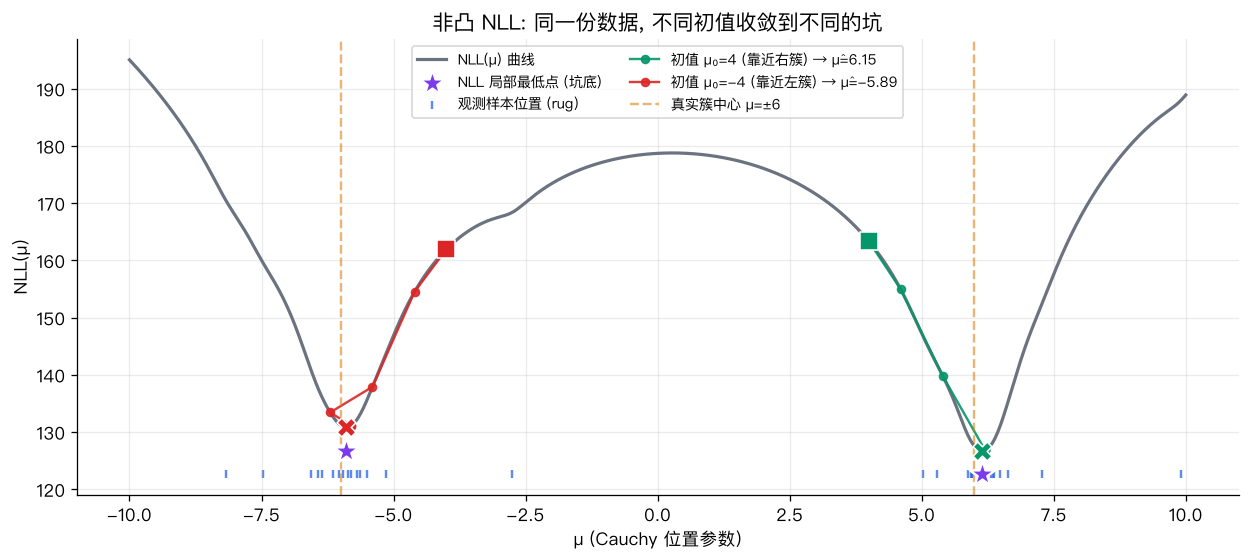

真实两簇中心: μ = -6 或 +6
从 μ₀= 4.0 出发 (靠近右簇): μ̂ = 6.1511   ← 落入右坑
从 μ₀=-4.0 出发 (靠近左簇): μ̂ = -5.8949   ← 落入左坑, 完全不同的解
右坑 NLL = 126.7401, 左坑 NLL = 130.8045
本次样本中 右坑 的 NLL 更低，是两个局部解中更好的全局候选。


In [12]:
# --- 6.6 演示: Cauchy 位置参数 MLE, 非凸 NLL 与初值陷阱 -----------------
# 关键: 两簇要"离得远 + 单簇 scale 小", 才能让 NLL 真的出现两个凹坑
# 主簇 15 个在 μ=6, 小簇 15 个在 μ=-6 (等大, 制造两个几乎对称的坑)
rng = np.random.default_rng(SEED)
x = np.concatenate([
    stats.cauchy.rvs(loc=6.0,  scale=0.3, size=15, random_state=rng),
    stats.cauchy.rvs(loc=-6.0, scale=0.3, size=15, random_state=rng),
])

def cauchy_nll(mu, x, scale=0.3):
    return -np.sum(stats.cauchy.logpdf(x, loc=mu, scale=scale))

mus = np.linspace(-10, 10, 800)
nll_curve = np.array([cauchy_nll(mu, x) for mu in mus])

def optimize_and_trace(mu0):
    trace = [mu0]
    def cb(xk):
        trace.append(float(xk[0]))
    res = optimize.minimize(lambda p: cauchy_nll(p[0], x), x0=[mu0],
                            method="Nelder-Mead", callback=cb,
                            options={"xatol": 1e-4, "fatol": 1e-4})
    trace.append(float(res.x[0]))
    return res.x[0], trace

# 初值分别放在两簇附近, 演示"下山下到最近的坑"
mu_hat_right, trace_right = optimize_and_trace(mu0=4.0)    # 起点在右簇附近
mu_hat_left,  trace_left  = optimize_and_trace(mu0=-4.0)   # 起点在左簇附近

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(mus, nll_curve, color=COLORS["gray"], lw=2, label="NLL(μ) 曲线")

# 标出局部极值 (坑底) —— 用窗口局部最小, 避免严格 < 在浮点平点漏检
from scipy.signal import argrelmin
local_min_idx = argrelmin(nll_curve, order=10)[0].tolist()
# 兜底: 如果 argrelmin 没找到, 用简单严格小于
if not local_min_idx:
    local_min_idx = [i for i in range(2, len(mus) - 2)
                     if nll_curve[i] < nll_curve[i-1] and nll_curve[i] < nll_curve[i+1]]
# 星标画在坑底稍下方, 作为"角标", 避免遮挡轨迹终点 X
star_offset = (nll_curve.max() - nll_curve.min()) * 0.06
for i in local_min_idx:
    ax.scatter([mus[i]], [nll_curve[i] - star_offset],
               color=COLORS["purple"], marker="*",
               s=280, zorder=4, edgecolor="white", linewidth=1.5)
if local_min_idx:
    ax.scatter([], [], color=COLORS["purple"], marker="*", s=280, edgecolor="white",
               linewidth=1.5, label="NLL 局部最低点 (坑底)")

ax.scatter(x, np.full_like(x, nll_curve.min() - 4),
           color=COLORS["blue"], alpha=0.75, s=30, marker="|",
           label="观测样本位置 (rug)")

for trace, color, label in [
    (trace_right, COLORS["green"],
     f"初值 μ₀=4 (靠近右簇) → μ̂={mu_hat_right:.2f}"),
    (trace_left,  COLORS["red"],
     f"初值 μ₀=-4 (靠近左簇) → μ̂={mu_hat_left:.2f}"),
]:
    ys = [cauchy_nll(t, x) for t in trace]
    ax.plot(trace, ys, marker="o", markersize=5, color=color, alpha=0.9, label=label)
    ax.scatter([trace[0]],  [ys[0]],  color=color, s=140, marker="s",
               edgecolor="white", zorder=6)
    ax.scatter([trace[-1]], [ys[-1]], color=color, s=140, marker="X",
               edgecolor="white", zorder=6)

ax.axvline( 6.0, color=COLORS["amber"], linestyle="--", alpha=0.55,
           label="真实簇中心 μ=±6")
ax.axvline(-6.0, color=COLORS["amber"], linestyle="--", alpha=0.55)
ax.set_xlabel("μ (Cauchy 位置参数)")
ax.set_ylabel("NLL(μ)")
ax.set_title("非凸 NLL: 同一份数据, 不同初值收敛到不同的坑")
ax.legend(loc="upper center", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

print(f"真实两簇中心: μ = -6 或 +6")
print(f"从 μ₀= 4.0 出发 (靠近右簇): μ̂ = {mu_hat_right:.4f}   ← 落入右坑")
print(f"从 μ₀=-4.0 出发 (靠近左簇): μ̂ = {mu_hat_left:.4f}   ← 落入左坑, 完全不同的解")
right_nll = cauchy_nll(mu_hat_right, x)
left_nll = cauchy_nll(mu_hat_left, x)
better_side = "右坑" if right_nll < left_nll else "左坑"
print(f"右坑 NLL = {right_nll:.4f}, 左坑 NLL = {left_nll:.4f}")
print(f"本次样本中 {better_side} 的 NLL 更低，是两个局部解中更好的全局候选。")
assert np.isfinite([right_nll, left_nll]).all()

### 6.7 看这张图 → 记住什么

- **灰色曲线** = NLL(μ)，我们要找**最低点**。它有**两个凹坑**（紫色星标）: 分别对应左簇 (μ≈-6) 和右簇 (μ≈+6)。两个坑深度相近, 中间被一段"山脊"隔开——**这就是"非凸": 山谷不止一个。**
- **蓝色 rug** = 30 个样本的位置。分别聚在 ±6 附近——**数据簇的位置直接塑造 NLL 曲线的形状**。
- **绿色轨迹**：从 $\mu_0 = 4$（方块起点）出发, 下山几步就到**右**簇凹坑底（X 终点）→ $\hat\mu \approx 6$。
- **红色轨迹**：从 $\mu_0 = -4$ 出发, 顺着山坡往左走, 停在**左**簇凹坑底 → $\hat\mu \approx -6$。**同一份数据, 只因为初值不同, 得到了完全不同的两个解。**

两个解都是**局部最优**（周围小范围内往任何方向移动都会让 NLL 上升），但它们的目标函数值未必相同：**NLL 更低的那个才是全局更优的候选**。数据有两个簇，所以两个坑都能解释一部分数据；非凸优化的困难不是“没有全局最优”，而是**局部优化器通常只保证找到附近的局部最优，不保证找到全局最低的那个坑**。

**核心结论**：**局部数值优化只保证不断改进并收敛到某个驻点，不保证落入全局最低的坑**。对于满足适当条件的凸问题，任意局部最优也是全局最优；但具体算法仍需要合适的步长、收敛条件和数值实现。神经网络的 loss 通常是高维非凸函数，因此初始化、随机批次和优化路径都会影响最终结果。

### 6.8 数值 MLE 的四大坑

| 坑 | 症状 | 缓解办法 |
|----|------|----------|
| **① 非凸导致的局部极值** (刚才那张图) | 相同数据、不同初值收敛到不同解；训练 loss 卡在一个"台阶"上不下降 | 多点初始化取最好那次；退火 / warmup；换更好的初始化 (Xavier / He) |
| **② 边界解** | Bernoulli 全正/全反时 $\hat\theta = 0$ 或 $1$；概率数值 $\to 0$ | 参数化变换 (优化 $\log\theta$ 而非 $\theta$)；加先验 → 走 MAP；label smoothing |
| **③ 数值不稳定** | likelihood 直接相乘下溢为 0；`exp` 上溢；`log(0) = -inf` | 全程走 log 空间：`logpdf`、`log_softmax`、`logsumexp`、`log1p` |
| **④ 模型误设** | 真实分布不属于你假设的族；模型再怎么调都拟合不好 | 检查残差直方图 / QQ 图；换更灵活的模型族 (混合模型、非参数方法) |

**一句话记忆**：训练神经网络遇到 "loss 卡住 / 突然爆炸 / 出现 NaN / 每次结果不一样"，这四条几乎能解释 80%。**你在调训练, 其实就是在跟这四个坑周旋**。

> **承上启下**：上表第 ② 坑"边界解"其实有一种非常优雅的解决办法——**加入先验**, 让极端解付出代价。这就是下一章 MAP 的动机, 也是"正则化"背后的数学原理。

## 7 · MLE、MAP 与贝叶斯：加入先验会发生什么？

### 7.1 MLE 缺"常识"

回到抛硬币场景：只抛了 3 次，观测 3 次全是正面。MLE 会告诉你 $\hat\theta = 3/3 = 1$——**下次抛出正面的概率是 100%**。这个结论显然不合理，但**MLE 就是这么"忠于数据"**——它只看观测，不带任何背景知识。

问题出在哪？在实际问题里, 我们对参数**几乎总是有一些先验信念**：

- 硬币的正面概率**接近 0.5**（工艺决定）。
- 神经网络的权重**接近 0**（否则激活会饱和 / 爆炸）。
- 生物年龄**是正数, 且集中在 0~120**。

MLE **完全丢掉了这些信息**。要把它们塞回来, 就走到贝叶斯框架。

### 7.2 贝叶斯公式：一句话概括

在参数上放一个**先验 $p(\theta)$**，然后按贝叶斯公式把先验"更新"成**后验**：

$$
\underbrace{p(\theta \mid x)}_{\text{后验}}
= \frac{\overbrace{p(x \mid \theta)}^{\text{似然}}\; \overbrace{p(\theta)}^{\text{先验}}}{\underbrace{p(x)}_{\text{证据 (常数)}}}
$$

分母 $p(x) = \int p(x\mid\theta) p(\theta) d\theta$ 与 $\theta$ 无关，做 argmax 时可以直接扔掉。这就得到 MAP。

### 7.3 MAP = MLE + 一项"先验对数"

**MAP (Maximum A Posteriori)** 选后验最高点作为估计：
$$
\hat\theta_{\text{MAP}} = \arg\max_\theta \big[\, \underbrace{\log p(x \mid \theta)}_{\text{MLE 项}} \;+\; \underbrace{\log p(\theta)}_{\text{先验项}} \,\big]
$$

在同一个 likelihood 下，MAP 的目标比 MLE 多了 $\log p(\theta)$。取负号后，$-\log p(\theta)$ 可以表现为正则项：

| 先验 $p(\theta)$ | $-\log p(\theta)$ | 深度学习里的名字 |
|------------------|-------------------|-------------------|
| $\theta \sim \mathcal N(0, \tau^2)$ | $\tfrac{1}{2\tau^2}\|\theta\|_2^2 + C$ | **L2 正则 / weight decay** |
| $\theta \sim \text{Laplace}(0, b)$ | $\tfrac{1}{b}\|\theta\|_1 + C$ | **L1 正则** (促稀疏) |
| $\theta \sim \text{均匀}$ | 常数 | 退化, MAP = MLE |
| 某些变分解释下的 dropout 先验 | 依模型与近似方法而定 | Dropout 可用于近似贝叶斯解释 |

**记住这条对应**：对 L2、L1 这类显式惩罚，**“给参数加正则”可以解释为“做带相应先验的 MAP”**。但具体先验方差不仅取决于 `weight_decay`，还取决于 loss 是求和还是求平均、正则项是否带 $1/2$、数据量以及优化器实现；例如 AdamW 的 decoupled weight decay 也不总与在 loss 中添加 L2 完全等价。因此不能只凭 `weight_decay=1e-4` 就唯一推出一个先验方差。

### 7.4 先花一分钟认识 Beta 分布

要做贝叶斯计算, 我们得挑一个先验分布来描述"你在看到数据前对 $\theta$ 的信念"。硬币问题里, $\theta$ 是一个概率, **只能取 $[0, 1]$ 之间的实数**。所以我们需要一个**只在 $[0, 1]$ 上有定义**的分布族——**Beta 分布** 就是干这个的。

**核心思想（不用记公式, 只记直觉）**：Beta 分布由**两个正参数** $\alpha$（读作 alpha）和 $\beta$（读作 beta）控制形状。可以把它们直接当成"你脑子里的虚拟观测":

$$
\boxed{\;\;\text{先验 Beta}(\alpha, \beta)\ =\ \text{"我脑子里已经预先看过\ } \alpha-1\text{ 个正面、}\beta-1\text{ 个反面"}\;\;}
$$

这条对应关系是理解 Beta 最重要的一步。有了它, 参数不再是数学抽象:

- $\alpha + \beta$ 越大 → 你"脑子里已经看过的次数"越多 → 先验越**尖锐、越顽固**
- $\dfrac{\alpha}{\alpha + \beta}$ = 你相信 $\theta$ **大概在哪里**（就是先验的均值）
- **$\alpha = \beta$** → 对 0 和 1 对称, 相信 $\theta$ 在 0.5 附近
- **$\alpha > \beta$** → 偏向 1（相信偏正面）
- **$\alpha < \beta$** → 偏向 0（相信偏反面）

**四种典型形状** (Beta 能捏出的常见模样):

| 参数 | 形状 | 语言描述 |
|------|------|----------|
| $\text{Beta}(1, 1)$ | 一条水平线 (**均匀分布**) | "我完全没意见, θ 什么值都可能" |
| $\text{Beta}(2, 2)$ | 温和的钟形, 峰在 0.5 | "更可能是接近公平的硬币, 但不太确定" |
| $\text{Beta}(10, 10)$ | 尖锐的钟形, 峰在 0.5 | "我很确定 θ 就在 0.5 附近" |
| $\text{Beta}(20, 2)$ | 峰偏右, 靠近 1 | "我相信这枚硬币被做过手脚, 偏正面" |

**代入具体数字**：$\text{Beta}(2, 2)$ 对应"心里虚拟看过 1 正 1 反"——温和地相信 0.5 但可以被推翻; $\text{Beta}(10, 10)$ 相当于"看过 9 正 9 反"——已经很确信是公平硬币了。

> **关于 PDF 公式**（可以跳过, 只是给感兴趣的读者）
>
> $p(\theta \mid \alpha, \beta) \propto \theta^{\alpha-1}\,(1-\theta)^{\beta-1}$
>
> 前面还有个归一化常数 $1/B(\alpha, \beta)$, 但和 $\theta$ 无关, 做 argmax 时可以扔掉。
>
> **注意**: 这个 $\theta^{\alpha-1}(1-\theta)^{\beta-1}$ **和第 3 章 Bernoulli 的似然 $\theta^k (1-\theta)^{n-k}$ 长得一模一样**——只是 $k \to \alpha-1$, $n-k \to \beta-1$。**这条巧合就是下一节所有魔法的来源**。

现在你只需要记住:

- **Beta 分布 = "用两个虚拟计数 $\alpha, \beta$ 表达的先验"**
- $\alpha + \beta$ 是信心强度, $\alpha / (\alpha+\beta)$ 是先验期望位置
- $\text{Beta}(1, 1)$ = 均匀, 什么都不假设

下一节我们看它和 Bernoulli 观测组合时会发生什么"魔法"。
下面把上表 4 种典型形状画出来, 再补 2 个 U 型 / 单峰偏斜的例子, 帮你把参数 $(\alpha, \beta)$ 和曲线长相对上号。

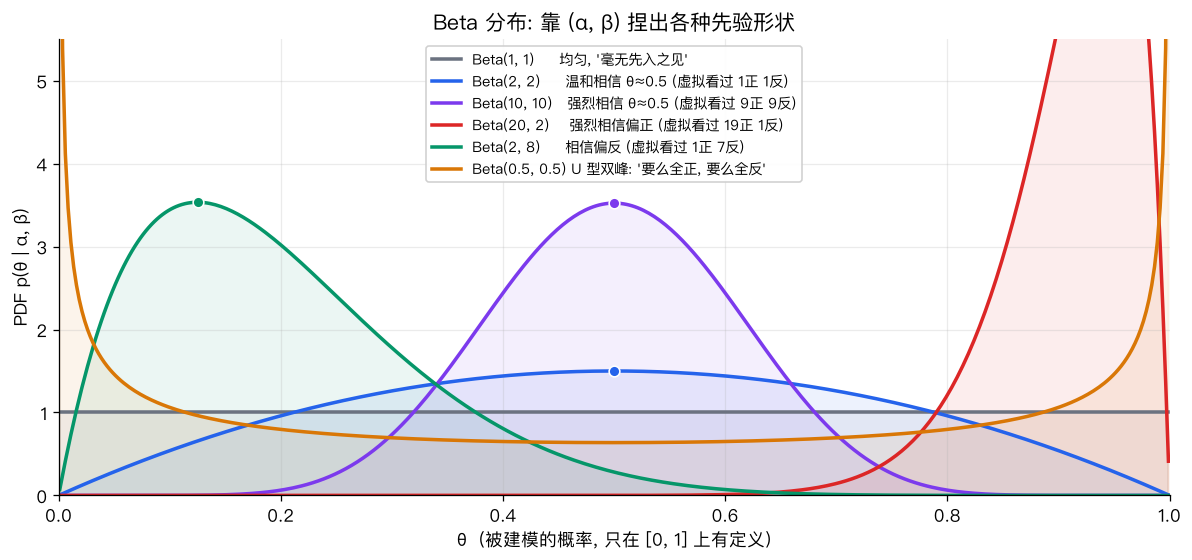

分布                 |    α |    β |     均值 α/(α+β) |         众数 (峰位置) |       信心强度 α+β
------------------------------------------------------------------------------------------------
Beta(1, 1)         |    1 |    1 |          0.500 |             无唯一峰 |              2
Beta(2, 2)         |    2 |    2 |          0.500 |            0.500 |              4
Beta(10, 10)       |   10 |   10 |          0.500 |            0.500 |             20
Beta(20, 2)        |   20 |    2 |          0.909 |            0.950 |             22
Beta(2, 8)         |    2 |    8 |          0.200 |            0.125 |             10
Beta(0.5, 0.5)     |  0.5 |  0.5 |          0.500 |             无唯一峰 |            1.0


In [13]:
# --- 7.4 Beta 分布的典型形状 ---------------------------------------------
thetas = np.linspace(0.001, 0.999, 400)

beta_examples = [
    (1,  1,  COLORS["gray"],    "Beta(1, 1)     均匀, '毫无先入之见'"),
    (2,  2,  COLORS["blue"],    "Beta(2, 2)     温和相信 θ≈0.5 (虚拟看过 1正 1反)"),
    (10, 10, COLORS["purple"],  "Beta(10, 10)   强烈相信 θ≈0.5 (虚拟看过 9正 9反)"),
    (20, 2,  COLORS["red"],     "Beta(20, 2)    强烈相信偏正 (虚拟看过 19正 1反)"),
    (2,  8,  COLORS["green"],   "Beta(2, 8)     相信偏反 (虚拟看过 1正 7反)"),
    (0.5, 0.5, COLORS["amber"], "Beta(0.5, 0.5) U 型双峰: '要么全正, 要么全反'"),
]

fig, ax = plt.subplots(figsize=(10.5, 5))
for alpha, beta, color, label in beta_examples:
    pdf = stats.beta.pdf(thetas, alpha, beta)
    ax.plot(thetas, pdf, color=color, lw=2.2, label=label)
    ax.fill_between(thetas, 0, pdf, color=color, alpha=0.08)
    if alpha > 1 and beta > 1:
        mode = (alpha - 1) / (alpha + beta - 2)
        ax.scatter([mode], [stats.beta.pdf(mode, alpha, beta)],
                   color=color, s=45, zorder=5, edgecolor="white", linewidth=1)

ax.set_xlim(0, 1)
ax.set_ylim(0, 5.5)
ax.set_xlabel("θ  (被建模的概率, 只在 [0, 1] 上有定义)")
ax.set_ylabel("PDF p(θ | α, β)")
ax.set_title("Beta 分布: 靠 (α, β) 捏出各种先验形状")
ax.legend(loc="upper center", fontsize=9, framealpha=0.92)
plt.tight_layout(); plt.show()

# 表格化输出关键统计量
print(f"{'分布':<18} | {'α':>4} | {'β':>4} | {'均值 α/(α+β)':>14} | {'众数 (峰位置)':>16} | {'信心强度 α+β':>14}")
print("-" * 96)
for alpha, beta, _, _ in beta_examples:
    mean_v = alpha / (alpha + beta)
    mode_v = f"{(alpha - 1) / (alpha + beta - 2):.3f}" if (alpha > 1 and beta > 1) else "无唯一峰"
    strength = alpha + beta
    print(f"{'Beta(' + str(alpha) + ', ' + str(beta) + ')':<18} | "
          f"{alpha:>4} | {beta:>4} | {mean_v:>14.3f} | {mode_v:>16} | {strength:>14}")

**看这张图**：

- **灰色平线 Beta(1, 1)** —— 均匀, 曲线完全水平, 每个 θ 的先验密度相等。"完全无先入之见"的先验。
- **蓝色 Beta(2, 2)** —— 温和的钟形, 峰在 0.5, 但很宽。相当于"看过 1 正 1 反 → 猜 0.5 但很不确定"。
- **紫色 Beta(10, 10)** —— 尖锐的钟形, 峰仍在 0.5。相当于"看过 9 正 9 反 → 很确信是公平硬币"。同样以 0.5 为中心, 比蓝色**尖锐 3-4 倍**——信心更强。
- **红色 Beta(20, 2)** —— 峰偏右, 靠近 0.9。"看过 19 正 1 反 → 相信偏正面"。
- **绿色 Beta(2, 8)** —— 峰偏左, 靠近 0.15。"看过 1 正 7 反 → 相信偏反面"。它和红色对称。
- **黄色 Beta(0.5, 0.5)** —— **U 型双峰**, 在 0 和 1 两端翘起, 中间凹陷。这是 $\alpha, \beta < 1$ 的特殊情形, 表达"我相信 θ 是极端值, 不太可能刚好中间"。

**规律速记**（对着图和表格验证）：

1. **均值 = $\alpha / (\alpha + \beta)$** —— 你相信 θ **大概在哪里**。Beta(2, 8) 的均值 = 0.2, 就是偏向左。
2. **信心强度 = $\alpha + \beta$** —— 曲线**尖锐程度**的指示器。10+10=20 比 2+2=4 尖 3-4 倍。
3. **$\alpha, \beta > 1$**: 有唯一峰 (单峰)。**$\alpha = \beta = 1$**: 均匀。**$\alpha, \beta < 1$**: U 型双峰。
4. **对称性**：Beta$(a, b)$ 和 Beta$(b, a)$ 关于 θ=0.5 镜像对称。所以红色和绿色是"镜像先验"。

现在你已经知道 Beta 分布长什么样、参数怎么捏形状。下一节我们看它和 Bernoulli 观测组合时会发生什么"魔法"。

### 7.5 一个可以精确算的例子：Beta-Bernoulli

现在把 7.4 认识的 Beta 先验 $\text{Beta}(\alpha, \beta)$ 和第 3 章的 Bernoulli 似然（抛 $n$ 次硬币观测到 $k$ 次正面）代入贝叶斯公式。**下面是全章唯一稍有跳跃的两行代数, 看完你就懂了。核心只有一个"眼睛观察"：先验和似然长得像不像？**

$$
\underbrace{p(\theta \mid k, n)}_{\text{后验}}
\;\propto\;
\underbrace{\theta^k (1-\theta)^{n-k}}_{\text{Bernoulli 似然}}
\;\cdot\;
\underbrace{\theta^{\alpha-1}(1-\theta)^{\beta-1}}_{\text{Beta 先验}}
= \theta^{\alpha+k-1}\,(1-\theta)^{\beta+n-k-1}
$$

**发现了吗**? 右边这个 $\theta^{\alpha+k-1}(1-\theta)^{\beta+n-k-1}$ **还是 Beta 分布的样子**, 只是参数从 $(\alpha, \beta)$ 变成了 $(\alpha+k, \beta+n-k)$！

$$
\boxed{\;\;\text{Beta}(\alpha, \beta)\ +\ (k\text{ 正}, n-k\text{ 反})\ \longrightarrow\ \text{Beta}(\alpha + k,\ \beta + n - k)\;\;}
$$

这个性质叫 **共轭先验 (conjugate prior)**: **先验和后验属于同一族分布, 观测数据只是把先验的参数"加"上去**。数学上极其漂亮, 计算上完全免费 (不需要跑 MCMC 或数值积分)。

**用上一节"虚拟计数"的直觉重新读一遍**：

- 先验 $\text{Beta}(\alpha, \beta)$ = 心里虚拟看过 "$\alpha - 1$ 正、$\beta - 1$ 反"。
- 观测：新看到 $k$ 正、$n-k$ 反。
- 后验：**心里的总账**变成 "$(\alpha - 1) + k$ 正、$(\beta - 1) + (n - k)$ 反"。
- 换成 Beta 参数写就是 $\text{Beta}(\alpha + k,\ \beta + n - k)$。

**MAP 和 MLE 的公式** (Beta 分布众数 = $\tfrac{a-1}{a+b-2}$):

$$
\hat\theta_{\text{MAP}} = \frac{\alpha + k - 1}{\alpha + \beta + n - 2},
\qquad
\hat\theta_{\text{MLE}} = \frac{k}{n}
$$

**手算一遍** —— 教程默认参数 $\alpha = \beta = 2$, $k = n = 3$（抛 3 次全正）:

- **先验** $\text{Beta}(2, 2)$: 心里已有 "1 正 1 反", 相信 $\theta \approx 0.5$。
- **观测**: 3 正 0 反。
- **后验** $\text{Beta}(2+3,\ 2+0) = \text{Beta}(5, 2)$: 心里总账变成 "4 正 1 反"。
- $\hat\theta_{\text{MAP}} = \dfrac{5-1}{5+2-2} = \dfrac{4}{5} = 0.8$
- $\hat\theta_{\text{MLE}} = 3/3 = 1.0$

**MLE 说"下次必为正 (1.0)"**, **MAP 因为多了 1 次虚拟反面的"底气", 拉回到 0.8**。这就是先验在小样本时的价值。

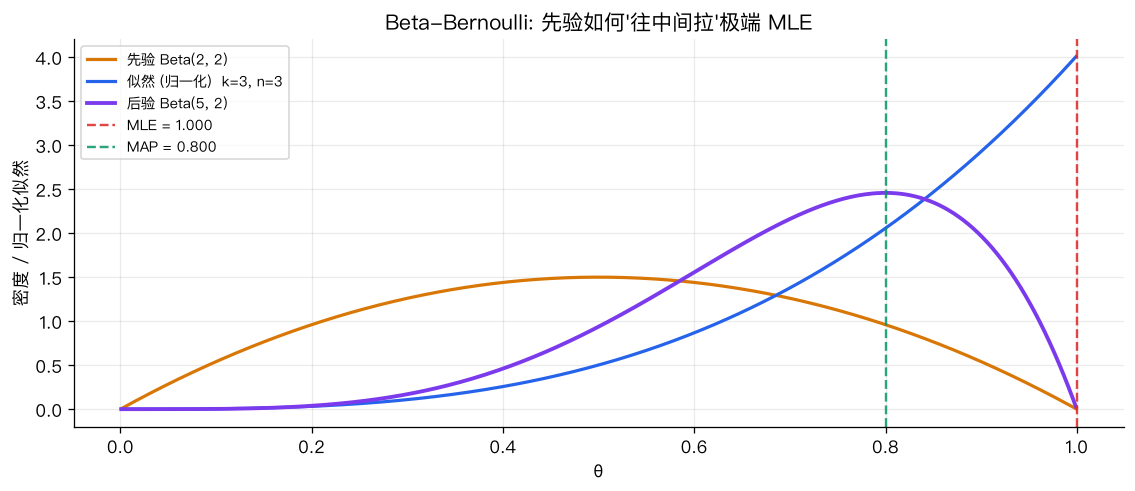

interactive(children=(IntSlider(value=3, description='k (正面)', max=3), IntSlider(value=3, description='n (总数)'…

In [14]:
# --- Prior / Likelihood / Posterior 三条曲线同轴对比 --------------------
def plot_prior_likelihood_posterior(k=3, n=3, alpha=2, beta=2):
    if n < 1:
        print("n 必须至少为 1"); return
    if not 0 <= k <= n:
        print(f"参数无效: 必须满足 0 ≤ k ≤ n，当前 k={k}, n={n}"); return
    if alpha <= 0 or beta <= 0:
        print("alpha 和 beta 必须为正数"); return
    thetas = np.linspace(0.001, 0.999, 400)
    prior = stats.beta.pdf(thetas, alpha, beta)
    likelihood = thetas**k * (1 - thetas)**(n - k)
    # 归一化 likelihood 以便画在同一坐标, 只影响视觉不影响 argmax
    _trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    likelihood_norm = likelihood / _trapz(likelihood, thetas)
    posterior = stats.beta.pdf(thetas, alpha + k, beta + n - k)

    # MLE 与 MAP 的解析点
    theta_mle = k / n if 0 < k < n else (0.0 if k == 0 else 1.0)
    a_post, b_post = alpha + k, beta + n - k
    if a_post > 1 and b_post > 1:
        theta_map = (a_post - 1) / (a_post + b_post - 2)
    else:
        theta_map = theta_mle

    fig, ax = plt.subplots(figsize=(10, 4.4))
    ax.plot(thetas, prior,           color=COLORS["amber"],  lw=2,
            label=f"先验 Beta({alpha}, {beta})")
    ax.plot(thetas, likelihood_norm, color=COLORS["blue"],   lw=2,
            label=f"似然 (归一化)  k={k}, n={n}")
    ax.plot(thetas, posterior,       color=COLORS["purple"], lw=2.4,
            label=f"后验 Beta({a_post}, {b_post})")
    ax.axvline(theta_mle, color=COLORS["red"], linestyle="--", alpha=0.85,
               label=f"MLE = {theta_mle:.3f}")
    ax.axvline(theta_map, color=COLORS["green"], linestyle="--", alpha=0.85,
               label=f"MAP = {theta_map:.3f}")
    ax.set_title("Beta-Bernoulli: 先验如何'往中间拉'极端 MLE")
    ax.set_xlabel("θ"); ax.set_ylabel("密度 / 归一化似然")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

# 默认: 3 次全正, 先验 Beta(2, 2) → 后验峰值不再是 1.0
plot_prior_likelihood_posterior(k=3, n=3, alpha=2, beta=2)
default_map = (2 + 3 - 1) / (2 + 2 + 3 - 2)
assert np.isclose(default_map, 0.8)

if HAS_WIDGETS:
    posterior_k_slider = IntSlider(value=3, min=0, max=3, step=1, description="k (正面)")
    posterior_n_slider = IntSlider(value=3, min=1, max=20, step=1, description="n (总数)")

    def sync_posterior_k_range(change):
        posterior_k_slider.max = change["new"]
        if posterior_k_slider.value > change["new"]:
            posterior_k_slider.value = change["new"]

    posterior_n_slider.observe(sync_posterior_k_range, names="value")
    interact(plot_prior_likelihood_posterior,
             k=posterior_k_slider,
             n=posterior_n_slider,
             alpha=FloatSlider(value=2, min=0.5, max=20, step=0.5, description="先验 α"),
             beta =FloatSlider(value=2, min=0.5, max=20, step=0.5, description="先验 β"));

### 7.6 看图观察: 先验如何"把 MLE 往中间拉"

- **橙色曲线 (先验)**: 观测数据之前对 $\theta$ 的信念。默认参数下是 $\text{Beta}(2, 2)$——温和地相信 $\theta$ 接近 0.5。
- **蓝色曲线 (归一化似然)**: 数据"说" $\theta$ 应该是多少。$k=n=3$ 时它单调递增, 在 $\theta = 1$ 处取最大——**这就是 MLE 会给出 1.0 的原因**。
- **紫色曲线 (后验)**: 两者的"相乘归一化"。峰值既不在先验中心, 也不在似然峰, **而是被两者拉扯到一个折中位置**——就是 MAP。
- **红色虚线**: MLE (1.0)。**绿色虚线**: MAP (0.8)。

拖动 widget 观察三条曲线的相对形状：

1. **加大 $\alpha, \beta$**（先验强度）: 后验更靠近先验中心, MAP 离 MLE 更远。
2. **加大 $n$**（数据量）: 似然越来越尖, 后验被似然拽走, MAP → MLE。
3. **保持 $k/n$ 不变、同步加大 $n$**: 无论先验多强, 数据量足够大时先验都被"洗掉"——**这正是"数据 dominance"的可视化**。

### 7.7 三种估计范式对比

| 范式 | 输出 | 用什么公式 | 深度学习类比 |
|------|------|------------|--------------|
| **MLE** | 一个点 $\hat\theta$ | $\arg\max \log p(x\|\theta)$ | 无正则化训练 |
| **MAP** | 一个点 $\hat\theta$ | $\arg\max [\log p(x\|\theta) + \log p(\theta)]$ | L2 / L1 等显式正则化训练 |
| **完整贝叶斯** | 整个后验分布 $p(\theta\|x)$ | 保留后验并做预测积分 | Bayesian NN, MCMC, 变分推断 |

**完整贝叶斯**不做点估计, 而是用整个后验做**预测积分**:
$$
p(x_{\text{new}} \mid x) = \int p(x_{\text{new}} \mid \theta)\, p(\theta \mid x)\, d\theta
$$
这自然带来**不确定性量化**——预测不仅有点估计，还可以得到后验预测区间。深度学习里的 Bayesian Neural Networks、变分推断和 MCMC 直接近似或采样后验；Deep Ensembles 与 MC Dropout 也是常用的不确定性估计方法，但前者不是完整贝叶斯推断，后者只有在特定假设下具有近似贝叶斯解释。

### 7.8 关键洞察

1. **MLE = 均匀先验下的 MAP**: 代入 $\text{Beta}(1, 1)$（=均匀）, MAP argmax 退化成 MLE argmax。所以 MLE 是 MAP 的一个特例, 不是对立面。
2. **样本量决定谁说了算**：在后验均值的加权解释中，$\alpha+\beta$ 常被称为先验有效样本量；在本节基于众数的“虚拟成功/失败计数”解释中，对应的是 $(\alpha-1)+(\beta-1)=\alpha+\beta-2$。当先验固定且正则条件成立、$n$ 持续增大时，likelihood 的影响通常占主导，MAP 会趋近 MLE。
3. **在小样本 / 高维 / 不平衡场景**（正是深度学习的常态）, 先验（正则化）就至关重要——它是把有限数据"外推"到高维空间的关键约束。
4. **共轭先验的价值不只在数学优美**: 后验参数可以在线增量更新（$\alpha \gets \alpha + k$, $\beta \gets \beta + n - k$）, 对应 **在线学习 / 序贯贝叶斯**——每来一批数据, 后验就滚动更新一次。

## 8 · 术语速查、常见误区与参考文献

### 8.1 术语速查

| 术语 | 中文 | 一句话解释 |
|------|------|----------|
| Likelihood $L(\theta)$ | 似然 | 固定数据看参数的评分函数 |
| Log-likelihood $\ell(\theta)$ | 对数似然 | log 后的似然, 数值稳定 |
| NLL | 负对数似然 | $-\ell$, 用来最小化 |
| MLE | 极大似然估计 | 让 $L$ (或 $\ell$) 最大的 $\theta$ |
| MAP | 最大后验估计 | 让后验 $p(\theta\|x)$ 最大的 $\theta$ |
| Prior | 先验 | 观测数据前对 $\theta$ 的信念 |
| Posterior | 后验 | 观测数据后对 $\theta$ 的信念 |
| Bias | 偏差 | $E[\hat\theta] - \theta$。Gaussian MLE 的 $\sigma^2$ 有偏 |
| Consistency | 一致性 | $\hat\theta \to \theta$ when $n \to \infty$ |
| Fisher Information | Fisher 信息 | $\ell$ 曲率 $-E[\ell''(\theta)]$, MLE 的方差下界 |
| Identifiability | 可辨识性 | 不同 $\theta$ 是否对应不同分布, 混合模型常见问题 |
| Sufficient Statistic | 充分统计量 | 保留数据全部似然信息的浓缩量 (如 Bernoulli 的 $\sum x_i$) |
| KL 散度 | Kullback-Leibler | MLE = 最小化经验分布到模型分布的 KL |

### 8.2 常见误区

- **误区 1**："似然是概率" —— **不是**。似然对参数不满足概率公理 (对 $\theta$ 积分不等于 1)。
- **误区 2**："MLE 一定无偏" —— **不是**。Gaussian $\sigma^2$ 的 MLE 就是有偏的 ($E[\hat\sigma^2] = \sigma^2\cdot(n-1)/n$)。在可辨识、参数位于内部、模型足够光滑等**正则条件**下，MLE 通常具有一致性、渐近正态性和渐近有效性；这些都不是对任意模型无条件成立的保证。
- **误区 3**："MLE 总是唯一" —— **不一定**。混合模型的 MLE 有 label-switching, 多个 $\theta$ 得到同样的 $L$；Cauchy 位置参数在样本对称时也可能非唯一。
- **误区 4**："只要 loss 是 MSE, 就等于假设高斯" —— 严格说, MSE 等价于**方差已知**的高斯 MLE。如果你想同时学 $\sigma$, 要用 Gaussian NLL loss。
- **误区 5**："神经网络里 loss 是 CE, 输出就是 softmax" —— 更准确: **CE + softmax 是 Categorical 分布的 MLE**。分类头换成 sigmoid + BCE, 就是 Bernoulli 的 MLE。
- **误区 6**："正则化和概率模型完全无关" —— L2、L1 等显式惩罚可以分别解释为 Gaussian、Laplace 先验下的 MAP，但 MAP 和 MLE 是不同的点估计准则，不能把 MAP 直接称为 MLE。
- **误区 7**："MLE 是频率派专属, 贝叶斯派用后验就不用 MLE" —— **不对**。贝叶斯里的**经验贝叶斯 (Empirical Bayes)** 常用 MLE 估计超参数, MLE 在两派里都是基础工具。

### 8.3 一页 MLE 全流程 (Cheat Sheet)

| 步骤 | 做什么 | 关键操作 | 为什么这么做 |
|------|--------|----------|--------------|
| **1** | 假设概率模型 | 写下 $p(x \mid \theta)$ | 这一步决定了后面损失长什么样 |
| **2** | 写联合似然 | $L(\theta) = \prod_i p(x_i \mid \theta)$ | i.i.d. 数据的联合密度 = 逐样本连乘 |
| **3** | 取对数 | $\ell(\theta) = \sum_i \log p(x_i \mid \theta)$ | 数值稳定（避免下溢）+ 便于求导（乘变加） |
| **4** | 转为最小化 | $\text{NLL}(\theta) = -\ell(\theta)$ | 对齐 "最小化" 这个统一优化接口 |
| **5** | 求 $\arg\min$ | 见下面 3 条路径 | 依赖模型复杂度 |

**Step 5 的三条路径**：

| 场景 | 方法 | 例子 |
|------|------|------|
| 简单指数族 | 求导 = 0，代数解 | Bernoulli → $k/n$；Gaussian → $\bar x$ |
| 一般模型 | 数值优化（SGD / Adam / L-BFGS）| 逻辑回归 / 神经网络 |
| 有先验 | $\arg\min\big[\text{NLL} - \log p(\theta)\big]$ | MAP / L2 / L1 正则化 |

**最终输出**：$\hat\theta$（点估计）+（可选）不确定性区间。频率学派通常构造**置信区间 (confidence interval)**；贝叶斯路径从后验分布构造**可信区间 (credible interval)**。二者可能数值接近，但概率解释不同。

### 8.4 从这里往下学什么？

- **EM 算法**：混合模型 / 隐变量下的 MLE，用"E 步求隐变量的后验、M 步做 MLE"迭代逼近。
- **贝叶斯推断**：MAP 之外的完整后验 (变分推断 VI, MCMC, HMC, NUTS)。
- **正则化与先验**：L2 <-> Gaussian prior、L1 <-> Laplace prior 是标准 MAP 对应；dropout、weight tying 等需要结合具体模型和推断假设讨论，不能一概视为严格等价。
- **信息论视角**：MLE = 最小化经验分布与模型分布的 KL 散度; 交叉熵 = KL + 数据熵。
- **Fisher information & Cramér–Rao 下界**：为什么 MLE 在样本量大的时候是**渐近有效**的 (方差达到理论下界)。
- **Score / Hessian based 方法**: Fisher scoring, Newton-Raphson, natural gradient——本质是"用曲率信息加速 MLE 收敛"。
- **广义线性模型 (GLM)**: 逻辑回归 / Poisson 回归 / Gamma 回归都是 MLE + link function 的直接应用。
- **深度生成模型**：Normalizing Flow 可直接优化 exact likelihood；VAE 最大化 ELBO（对 log likelihood 的下界）；扩散模型常通过变分界、去噪目标或 score matching 建立与 likelihood 建模的联系。三者与似然的关系不同。

### 8.5 参考文献

- Fisher, R. A. (1922). *On the Mathematical Foundations of Theoretical Statistics.* Phil. Trans. R. Soc. A.
- Casella, G., & Berger, R. L. (2002). *Statistical Inference* (2nd ed.). Duxbury.
- Wasserman, L. (2004). *All of Statistics: A Concise Course in Statistical Inference.* Springer.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning.* Springer. (Ch. 2 & 3)
- Murphy, K. P. (2012). *Machine Learning: A Probabilistic Perspective.* MIT Press. (Ch. 4 & 8)
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning.* MIT Press. (Ch. 5.5 Maximum Likelihood Estimation)

---

**恭喜你读到这里** 🎓 —— 现在你不仅知道 MLE 是什么, 还应该能:

- 用一枚硬币解释"概率 vs 似然"的视角差异;
- 手推 Bernoulli / Gaussian MLE, 说清楚 $\sigma^2$ 为什么有偏;
- 说清楚 BCE / MSE / CE 都是特定分布下的 NLL, 并用曲线形状反推概率假设;
- 用 `scipy.optimize` 解一个没有闭式解的 MLE, 并解释非凸 / 边界 / 数值 / 误设四大坑;
- 说清楚 MAP 与 MLE 差在 "$+\log p(\theta)$", 正则化就是先验的对数;
- 沿着上面 8.4 的地图, 走向 EM / 贝叶斯 / 生成模型 / 信息论 / GLM 等下一站。